In [1]:
# %%
import os
import sys
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import defaultdict

sys.path.append(os.path.abspath('..'))

if os.path.basename(os.getcwd()) in ['notebook', 'scripts']:
    os.chdir('..')
    print("New Working Directory:", os.getcwd())

sns.set_theme(style="whitegrid", palette="muted")

New Working Directory: /home/nikodem/Workspace/3-sem-mgr/eapgt


In [2]:
# %%
configs = {
    'Classic': './config/eap/zinc/graphformer_ba_classic.yaml',
    'MPNN_Attention': './config/eap/zinc/graphformer_ba_mpnn_attention.yaml'
}

data = {}

for name, path in configs.items():
    if not os.path.exists(path):
        print(f"Warning: Config {path} not found.")
        continue
        
    with open(path, 'r') as f:
        config = yaml.safe_load(f)
        
    save_dir = os.path.join("", config['experiment']['save_dir'])
    
    # Load Macros, Masks, and Micros
    try:
        macro_path = os.path.join(save_dir, 'global_macro_attributions.pt')
        mask_path = os.path.join(save_dir, 'optimal_masks.pt')
        micro_path = os.path.join(save_dir, 'micro_edges_raw.pt')

        print(f"macro_path {macro_path}")
        data[name] = {
            'macro': torch.load(macro_path, map_location='cpu') if os.path.exists(macro_path) else {},
            'masks': torch.load(mask_path, map_location='cpu') if os.path.exists(mask_path) else {},
            'micro': torch.load(micro_path, map_location='cpu') if os.path.exists(micro_path) else []
        }
        print(f"Loaded {name} from {save_dir}")
    except Exception as e:
        print(f"Error loading {name}: {e}")

macro_path ./outputs/eap_results/zinc/graphformer/classic/global_macro_attributions.pt
Loaded Classic from ./outputs/eap_results/zinc/graphformer/classic/
macro_path ./outputs/eap_results/zinc/graphformer/attention/global_macro_attributions.pt
Loaded MPNN_Attention from ./outputs/eap_results/zinc/graphformer/attention/


In [3]:
# %%
def get_active_non_mpnn_components(masks_dict):
    """Returns a set of active components that are NOT M, A, or U."""
    active = set()
    for comp, mask in masks_dict.items():
        if isinstance(mask, torch.Tensor):
            is_active = (mask > 0).any().item()
        else:
            is_active = mask > 0
            
        if is_active:
            if not comp.endswith(('.M', '.A', '.U')):
                active.add(comp)
    return active

active_components = {}
for name, run_data in data.items():
    if 'masks' in run_data and run_data['masks']:
        active_components[name] = get_active_non_mpnn_components(run_data['masks'])

print("--- Surviving Non-MPNN Components ---")
all_unique_comps = set.union(*active_components.values()) if active_components else set()

for comp in sorted(all_unique_comps):
    status = []
    for name in configs.keys():
        if name in active_components:
            status.append(f"{name}: {'✅' if comp in active_components[name] else '❌'}")
    print(f"{comp:<30} | {' | '.join(status)}")

--- Surviving Non-MPNN Components ---
hf_model.classifier            | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encoder.layers.0.fc1 | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encoder.layers.0.fc2 | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encoder.layers.0.self_attn | Classic: ✅ | MPNN_Attention: ❌
hf_model.encoder.graph_encoder.layers.1.fc1 | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encoder.layers.1.fc2 | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encoder.layers.1.self_attn | Classic: ✅ | MPNN_Attention: ❌
hf_model.encoder.graph_encoder.layers.10.fc1 | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encoder.layers.10.fc2 | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encoder.layers.10.self_attn | Classic: ✅ | MPNN_Attention: ❌
hf_model.encoder.graph_encoder.layers.11.fc1 | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encoder.layers.11.fc2 | Classic: ✅ | MPNN_Attention: ✅
hf_model.encoder.graph_encod

In [4]:
import pandas as pd

def get_comparison_df(data):
    # Get all unique module names across both experiments
    all_modules = sorted(list(set(data['Classic']['masks'].keys()) | set(data['MPNN_Attention']['masks'].keys())))
    
    comparison_results = []
    for mod in all_modules:
        # Check if the module survived (mask value is 1)
        classic_survived = data['Classic']['masks'].get(mod, 0.0) > 0
        attention_survived = data['MPNN_Attention']['masks'].get(mod, 0.0) > 0
        
        comparison_results.append({
            'Component': mod,
            'Classic': '✅' if classic_survived else '❌',
            'MPNN_Attention': '✅' if attention_survived else '❌'
        })
        
    df = pd.DataFrame(comparison_results)
    return df

# Generate the table
df_comp = get_comparison_df(data)

# Filter to show only the Encoder Layers to make it readable
df_layers = df_comp[df_comp['Component'].str.contains('layers')].copy()

# Add a 'Layer' column for sorting
df_layers['layer_idx'] = df_layers['Component'].str.extract(r'layers\.(\d+)').astype(int)
df_layers = df_layers.sort_values(['layer_idx', 'Component'])

print("--- Detailed Pruning Comparison per Layer ---")
print(df_layers[['Component', 'Classic', 'MPNN_Attention']].to_string(index=False))

# Optional: Show only the ones that differ
diff = df_layers[df_layers['Classic'] != df_layers['MPNN_Attention']]
print("\n--- Components where the experiments DISAGREED ---")
print(diff[['Component', 'Classic', 'MPNN_Attention']].to_string(index=False))

--- Detailed Pruning Comparison per Layer ---
                                           Component Classic MPNN_Attention
         hf_model.encoder.graph_encoder.layers.0.fc1       ✅              ✅
         hf_model.encoder.graph_encoder.layers.0.fc2       ✅              ✅
   hf_model.encoder.graph_encoder.layers.0.self_attn       ✅              ❌
 hf_model.encoder.graph_encoder.layers.0.self_attn.A       ❌              ✅
 hf_model.encoder.graph_encoder.layers.0.self_attn.M       ❌              ✅
 hf_model.encoder.graph_encoder.layers.0.self_attn.U       ❌              ✅
         hf_model.encoder.graph_encoder.layers.1.fc1       ✅              ✅
         hf_model.encoder.graph_encoder.layers.1.fc2       ✅              ✅
   hf_model.encoder.graph_encoder.layers.1.self_attn       ✅              ❌
 hf_model.encoder.graph_encoder.layers.1.self_attn.A       ❌              ✅
 hf_model.encoder.graph_encoder.layers.1.self_attn.M       ❌              ✅
 hf_model.encoder.graph_encoder.layers.1.s

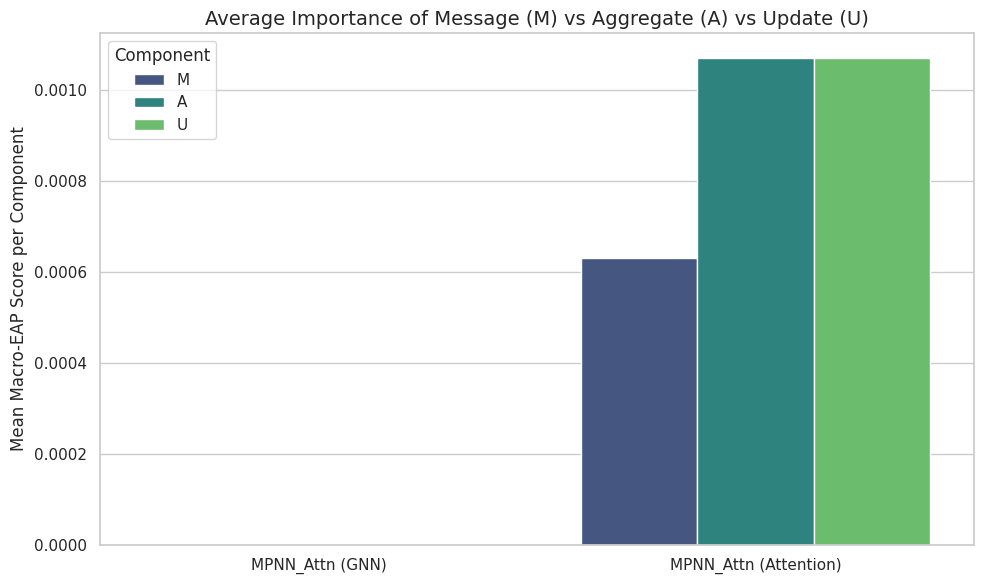

In [5]:
# %%
def aggregate_mau_scores(macro_scores):
    # Store data as [total_score, count] to calculate the mean later
    stats = {
        'GNN': {'M': [0.0, 0], 'A': [0.0, 0], 'U': [0.0, 0]}, 
        'Attention': {'M': [0.0, 0], 'A': [0.0, 0], 'U': [0.0, 0]}
    }
    
    for comp, score in macro_scores.items():
        score_val = score.item() if isinstance(score, torch.Tensor) else score
        
        comp_type = comp.split('.')[-1]
        if comp_type in ['M', 'A', 'U']:
            # GraphGPS uses 'conv' for local MPNN and 'attn' for global attention
            if 'conv' in comp.lower() or 'mpnn' in comp.lower():
                stats['GNN'][comp_type][0] += score_val
                stats['GNN'][comp_type][1] += 1
            elif 'attn' in comp.lower() or 'mha' in comp.lower() or 'multihead' in comp.lower():
                stats['Attention'][comp_type][0] += score_val
                stats['Attention'][comp_type][1] += 1
            else:
                # Fallback if names are generic
                stats['GNN'][comp_type][0] += score_val 
                stats['GNN'][comp_type][1] += 1
                
    # Calculate the mean (total_score / count)
    summary = {'GNN': {}, 'Attention': {}}
    for arch in ['GNN', 'Attention']:
        for c_type in ['M', 'A', 'U']:
            total_score, count = stats[arch][c_type]
            summary[arch][c_type] = total_score / count if count > 0 else 0.0
            
    return summary

plot_data = []

if 'MPNN' in data:
    mpnn_mau = aggregate_mau_scores(data['MPNN']['macro'])
    for comp, val in mpnn_mau['GNN'].items():
        plot_data.append({'Run': 'MPNN (GNN only)', 'Component': comp, 'Score': val})

if 'MPNN_Attention' in data:
    attn_mau = aggregate_mau_scores(data['MPNN_Attention']['macro'])
    for comp, val in attn_mau['GNN'].items():
        plot_data.append({'Run': 'MPNN_Attn (GNN)', 'Component': comp, 'Score': val})
    for comp, val in attn_mau['Attention'].items():
        plot_data.append({'Run': 'MPNN_Attn (Attention)', 'Component': comp, 'Score': val})

df_mau = pd.DataFrame(plot_data)
sys.path.append(os.path.abspath('..'))

if os.path.basename(os.getcwd()) in ['notebooks', 'scripts']:
    os.chdir('..')
    print("New Working Directory:", os.getcwd())

sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 6))
sns.barplot(data=df_mau, x='Run', y='Score', hue='Component', palette='viridis')
plt.title("Average Importance of Message (M) vs Aggregate (A) vs Update (U)", fontsize=14)
plt.ylabel("Mean Macro-EAP Score per Component")
plt.xlabel("")
plt.tight_layout()
plt.show()

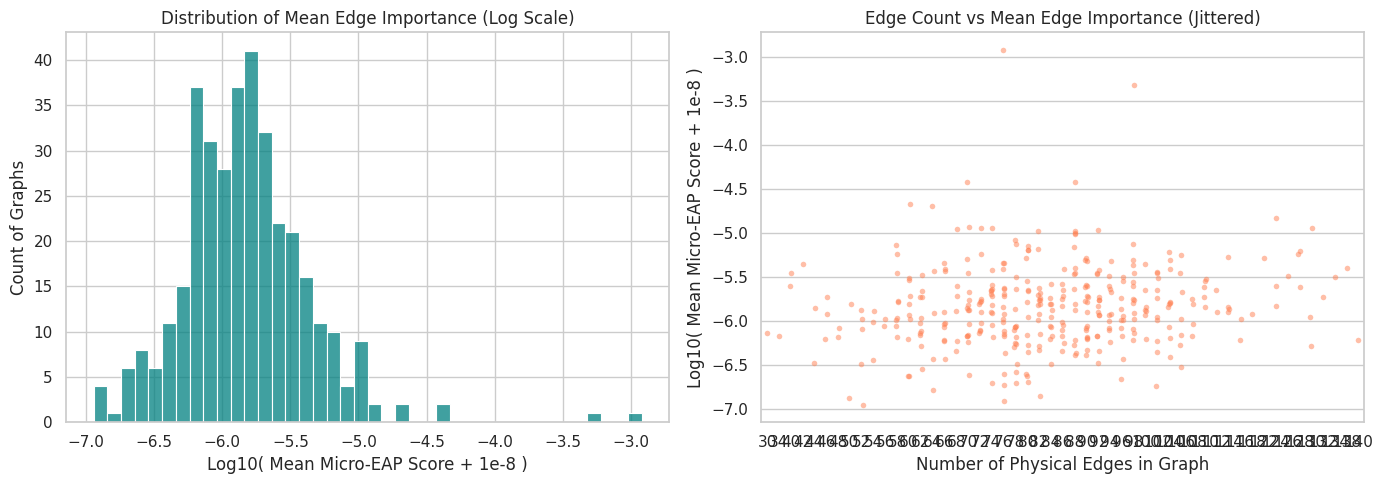

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# We will use the MPNN_Attention run to get the richest structural data
if 'MPNN_Attention' in data and data['MPNN_Attention']['micro']:
    micro_list = data['MPNN_Attention']['micro']
    
    # 1. Calculate Mean Edge Value per Graph
    graph_means = []
    for graph_data in micro_list:
        num_physical_edges = graph_data['edge_index'].shape[1]
        
        # CHANGED: Adjusted filtering for Graphormer/Dense Attention. 
        # We drop the '.M' strict check and shape check to see what data we actually have.
        # If you specifically want attention, we look for 'attn' or similar in the key.
        m_scores = [
            v for k, v in graph_data['micro_scores'].items() 
            if 'attn' in k.lower() or k.endswith('.M') 
        ]
        
        if m_scores:
            # Note: Because Graphormer produces NxN attention, sum() might need tweaking 
            # depending on if you want to sum over heads or nodes.
            total_edge_scores = torch.stack(m_scores).sum(dim=0)
            graph_means.append({
                'graph_index': graph_data['graph_index'],
                'mean_edge_score': total_edge_scores.mean().item(),
                'max_edge_score': total_edge_scores.max().item(),
                'num_edges': num_physical_edges
            })
            
    df_micro = pd.DataFrame(graph_means)
    
    # SAFETY CHECK: Ensure we actually captured data before plotting
    if df_micro.empty:
        print("⚠️ No modules matched the filtering criteria! graph_means is empty.")
        print("Here are the actual keys and shapes available in your first graph's micro_scores:")
        for k, v in micro_list[0]['micro_scores'].items():
            print(f"  - Key: '{k}' | Shape: {v.shape}")
    else:
        # ADDED: Apply Log10 scale (with small epsilon to prevent log(0) errors)
        df_micro['log_mean_score'] = np.log10(df_micro['mean_edge_score'] + 1e-8)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Use the Log-scaled scores for the histogram
        sns.histplot(df_micro['log_mean_score'], bins=40, ax=ax1, color='teal')
        ax1.set_title("Distribution of Mean Edge Importance (Log Scale)")
        ax1.set_xlabel("Log10( Mean Micro-EAP Score + 1e-8 )")
        ax1.set_ylabel("Count of Graphs")
        
        # CHANGED: Use a stripplot to add jitter so we can see overlapping dots!
        sns.stripplot(
            data=df_micro, 
            x='num_edges', 
            y='log_mean_score', 
            ax=ax2, 
            color='coral', 
            alpha=0.5, 
            jitter=True,
            size=4
        )
        
        ax2.set_title("Edge Count vs Mean Edge Importance (Jittered)")
        ax2.set_xlabel("Number of Physical Edges in Graph")
        ax2.set_ylabel("Log10( Mean Micro-EAP Score + 1e-8 )")
        
        plt.tight_layout()
        plt.show()
else:
    print("Micro-EAP data not found for MPNN_Attention.")

In [7]:
# %%
if 'MPNN_Attention' in data and data['MPNN_Attention']['micro']:
    micro_list_mpnn = data['MPNN_Attention']['micro']
    
    # 1. Build DataFrame specifically for MPNN
    graph_means_mpnn = []
    for graph_data in micro_list:
        num_physical_edges = graph_data['edge_index'].shape[1]
        
        # CHANGED: Adjusted filtering for Graphormer/Dense Attention. 
        # We drop the '.M' strict check and shape check to see what data we actually have.
        # If you specifically want attention, we look for 'attn' or similar in the key.
        m_scores = [
            v for k, v in graph_data['micro_scores'].items() 
            if 'attn' in k.lower() or k.endswith('.M') 
        ]
        
        if m_scores:
            # Note: Because Graphormer produces NxN attention, sum() might need tweaking 
            # depending on if you want to sum over heads or nodes.
            total_edge_scores = torch.stack(m_scores).sum(dim=0)
            graph_means_mpnn.append({
                'graph_index': graph_data['graph_index'],
                'mean_edge_score': total_edge_scores.mean().item(),
                'max_edge_score': total_edge_scores.max().item(),
                'std_edge_score': total_edge_scores.std().item(),
                'min_edge_score': total_edge_scores.min().item(),
                'num_edges': num_physical_edges
            })
            
    # for graph_data in micro_list_mpnn:
    #     num_physical_edges = graph_data['edge_index'].shape[1]
        
    #     # Filter for 1D structural Message modules
    #     m_scores = [
    #         v for k, v in graph_data['micro_scores'].items() 
    #         if k.endswith('.M') and v.shape == (num_physical_edges,)
    #     ]
        
    #     if m_scores:
    #         total_edge_scores = torch.stack(m_scores).sum(dim=0)
    #         graph_means_mpnn.append({
    #             'graph_index': graph_data['graph_index'],
    #             'mean_edge_score': total_edge_scores.mean().item(),
    #             'std_edge_score': total_edge_scores.std().item(),
    #             'max_edge_score': total_edge_scores.max().item(),
    #             'min_edge_score': total_edge_scores.min().item(),
    #             'num_edges': num_physical_edges
    #         })
            
    df_micro_mpnn = pd.DataFrame(graph_means_mpnn)
    
    print("--- Summary Statistics for MPNN Micro-EAP Edge Scores ---")
    display(df_micro_mpnn.describe())
    
    print("\n--- Top 5 Graphs with Highest Maximum Edge Score ---")
    display(df_micro_mpnn.sort_values(by='max_edge_score', ascending=False).head())
else:
    print("Micro-EAP data not found for MPNN.")

--- Summary Statistics for MPNN Micro-EAP Edge Scores ---


,graph_index,mean_edge_score,max_edge_score,std_edge_score,min_edge_score,num_edges
count,358.000000,3.580000e+02,358.000000,3.580000e+02,3.580000e+02,358.000000
mean,178.500000,7.098135e-06,0.000969,4.798014e-05,1.264717e-09,83.418994
std,103.489935,6.829292e-05,0.008643,4.716286e-04,7.578928e-09,19.080190
min,0.000000,1.037440e-07,0.000016,7.905987e-07,0.000000e+00,30.000000
25%,89.250000,7.220438e-07,0.000084,4.492222e-06,0.000000e+00,70.000000
50%,178.500000,1.376838e-06,0.000182,8.418560e-06,0.000000e+00,82.000000
75%,267.750000,2.521142e-06,0.000399,1.593905e-05,0.000000e+00,96.000000
max,357.000000,1.202882e-03,0.147120,8.292703e-03,7.717250e-08,140.000000



--- Top 5 Graphs with Highest Maximum Edge Score ---


,graph_index,mean_edge_score,max_edge_score,std_edge_score,min_edge_score,num_edges
41,41,0.001203,0.147120,0.008293,0.0,76
80,80,0.000479,0.071914,0.003334,0.0,98
234,234,0.000038,0.007151,0.000299,0.0,70
254,254,0.000038,0.006291,0.000279,0.0,88
340,340,0.000015,0.002823,0.000084,0.0,124


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

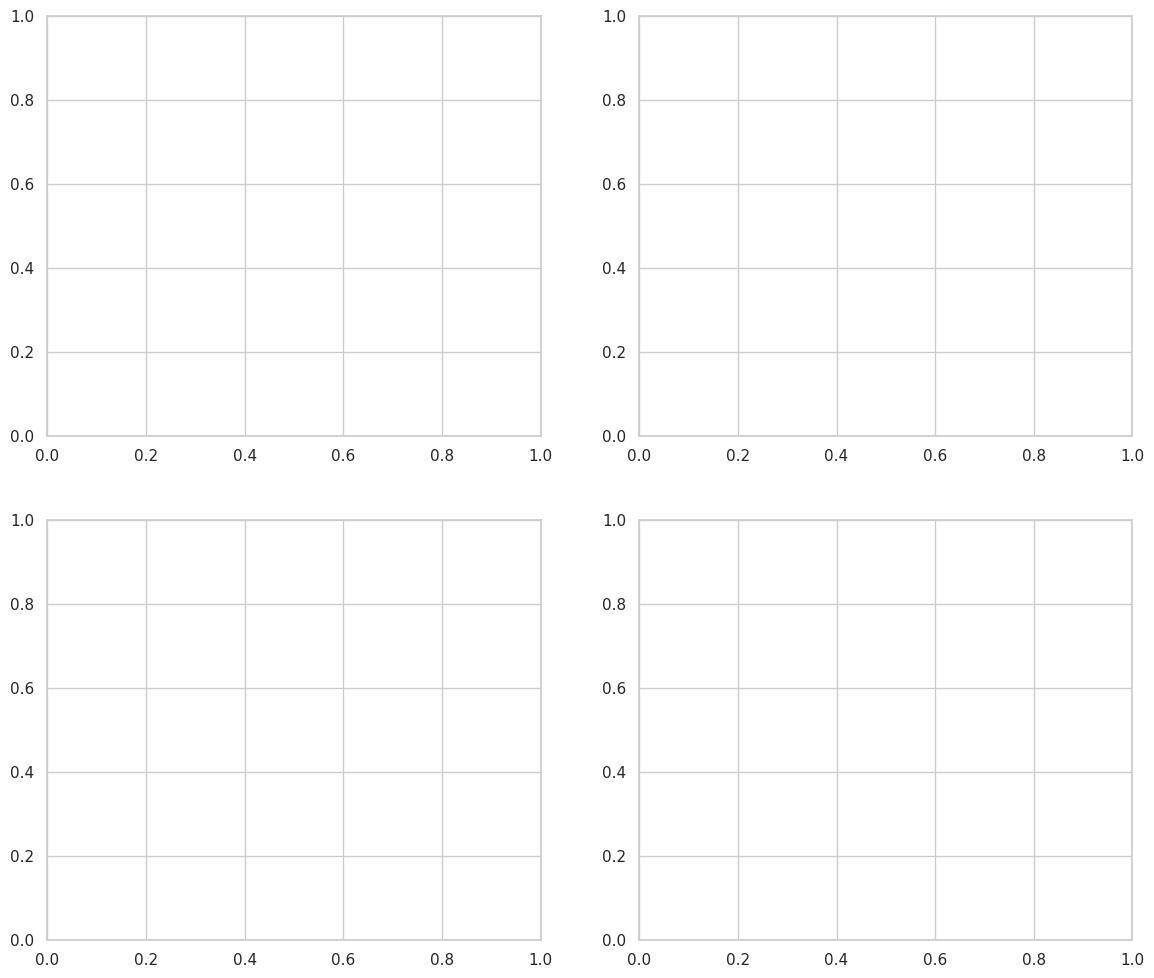

In [8]:
# %%
if 'MPNN_Attention' in data and data['MPNN_Attention']['micro'] and not df_micro_mpnn.empty:
    # Let's plot the top 4 graphs with the most important structural signals
    top_4_indices = df_micro_mpnn.sort_values(by='max_edge_score', ascending=False).head(4)['graph_index'].values
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for ax_idx, g_idx in enumerate(top_4_indices):
        target_data = next(g for g in micro_list_mpnn if g['graph_index'] == g_idx)
        edge_index = target_data['edge_index'].numpy()
        num_physical_edges = edge_index.shape[1]
        
        # --- NEW: Extract the Graph Label ---
        # First, try to get it from the dataset we loaded in Cell 9
        if 'df_labels' in locals():
            label = df_labels.loc[df_labels['graph_index'] == g_idx, 'label'].iloc[0]
        else:
            # Fallback: check if it's saved inside the micro_scores data directly
            y_val = target_data.get('y', target_data.get('label', 'Unknown'))
            if isinstance(y_val, torch.Tensor):
                label = y_val.item() if y_val.numel() == 1 else y_val[0].item()
            else:
                label = y_val
        # ------------------------------------
        
        # Filter and Aggregate
        # m_scores = [
        #     v for k, v in target_data['micro_scores'].items() 
        #     if k.endswith('.M') and v.shape == (num_physical_edges,)
        # ]
        m_scores = [
            v for k, v in graph_data['micro_scores'].items() 
            if 'attn' in k.lower() or k.endswith('.M') 
        ]
        
        if m_scores:
            edge_weights = torch.stack(m_scores).sum(dim=0).numpy()
            # Normalize weights for plotting
            edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)
            
            # Build NetworkX Graph
            G = nx.Graph() 
            for i in range(num_physical_edges):
                src, dst = edge_index[0, i], edge_index[1, i]
                if G.has_edge(src, dst):
                    G[src][dst]['weight'] = max(G[src][dst]['weight'], edge_weights_norm[i])
                else:
                    G.add_edge(src, dst, weight=edge_weights_norm[i])
                    
            edges = G.edges(data=True)
            # Make the most important edges even thicker to stand out
            weights = [d['weight'] * 6 for u, v, d in edges] 
            colors = [d['weight'] for u, v, d in edges]
            
            # Use spring_layout with high 'k' to push nodes apart
            pos = nx.spring_layout(G, k=0.5, iterations=200, seed=42)
            
            nx.draw_networkx_nodes(G, pos, ax=axes[ax_idx], node_size=80, node_color='skyblue', edgecolors='black')
            
            edges_drawn = nx.draw_networkx_edges(
                G, pos, ax=axes[ax_idx],
                width=weights, 
                edge_color=colors, 
                edge_cmap=plt.cm.magma_r, 
                alpha=0.8
            )
            
            # CHANGED: Added "Class {label}" to the title
            axes[ax_idx].set_title(f"Graph {g_idx} - Class {label}\n(Max Score: {df_micro_mpnn[df_micro_mpnn['graph_index']==g_idx]['max_edge_score'].iloc[0]:.4f})", fontsize=12)
            axes[ax_idx].axis("off")
            
            # Add a single colorbar for all subplots based on the first plot
            if ax_idx == 0:
                cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
                fig.colorbar(edges_drawn, cax=cbar_ax, orientation='horizontal', label="Micro-EAP Edge Importance (Normalized)")

    fig.suptitle("Most Important Structural Motifs across Top 4 Graphs (MPNN Run)", fontsize=16)
    # Adjust layout to make room for colorbar at the bottom
    plt.tight_layout(rect=[0, 0.08, 1, 0.96]) 
    plt.show()
else:
    print("Could not generate plots. Missing MPNN data.")

In [9]:
# %%
if 'MPNN' in data and data['MPNN']['micro'] and not df_micro.empty:
    # Let's plot the top 4 graphs with the most important structural signals in the MPNN_Attention run
    top_4_indices = df_micro.sort_values(by='max_edge_score', ascending=False).head(4)['graph_index'].values
    
    micro_list_attn = data['MPNN']['micro']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for ax_idx, g_idx in enumerate(top_4_indices):
        target_data = next(g for g in micro_list_attn if g['graph_index'] == g_idx)
        edge_index = target_data['edge_index'].numpy()
        num_physical_edges = edge_index.shape[1]
        
        # --- Extract the Graph Label ---
        if 'df_labels' in locals():
            label = df_labels.loc[df_labels['graph_index'] == g_idx, 'label'].iloc[0]
        else:
            # Fallback: check if it's saved inside the micro_scores data directly
            y_val = target_data.get('y', target_data.get('label', 'Unknown'))
            if isinstance(y_val, torch.Tensor):
                label = y_val.item() if y_val.numel() == 1 else y_val[0].item()
            else:
                label = y_val
        # ------------------------------------
        
        # Filter and Aggregate ONLY local MPNN structural messages (1D tensors)
        m_scores = [
            v for k, v in target_data['micro_scores'].items() 
            if k.endswith('.M') and v.shape == (num_physical_edges,)
        ]
        
        if m_scores:
            edge_weights = torch.stack(m_scores).sum(dim=0).numpy()
            # Normalize weights for plotting
            edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)
            
            # Build NetworkX Graph
            G = nx.Graph() 
            for i in range(num_physical_edges):
                src, dst = edge_index[0, i], edge_index[1, i]
                if G.has_edge(src, dst):
                    G[src][dst]['weight'] = max(G[src][dst]['weight'], edge_weights_norm[i])
                else:
                    G.add_edge(src, dst, weight=edge_weights_norm[i])
                    
            edges = G.edges(data=True)
            # Make the most important edges even thicker to stand out
            weights = [d['weight'] * 6 for u, v, d in edges] 
            colors = [d['weight'] for u, v, d in edges]
            
            # Use spring_layout with high 'k' to push nodes apart
            pos = nx.spring_layout(G, k=0.5, iterations=200, seed=42)
            
            nx.draw_networkx_nodes(G, pos, ax=axes[ax_idx], node_size=80, node_color='lightgreen', edgecolors='black')
            
            edges_drawn = nx.draw_networkx_edges(
                G, pos, ax=axes[ax_idx],
                width=weights, 
                edge_color=colors, 
                edge_cmap=plt.cm.magma_r, 
                alpha=0.8
            )
            
            axes[ax_idx].set_title(f"Graph {g_idx} - Class {label}\n(Max Score: {df_micro[df_micro['graph_index']==g_idx]['max_edge_score'].iloc[0]:.4f})", fontsize=12)
            axes[ax_idx].axis("off")
            
            # Add a single colorbar for all subplots based on the first plot
            if ax_idx == 0:
                cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
                fig.colorbar(edges_drawn, cax=cbar_ax, orientation='horizontal', label="Micro-EAP Edge Importance (Normalized)")

    fig.suptitle("Most Important Structural (MPNN) Motifs across Top 4 Graphs (MPNN_Attention Run)", fontsize=16)
    # Adjust layout to make room for colorbar at the bottom
    plt.tight_layout(rect=[0, 0.08, 1, 0.96]) 
    plt.show()
else:
    print("Could not generate plots. Missing MPNN_Attention data.")

Could not generate plots. Missing MPNN_Attention data.


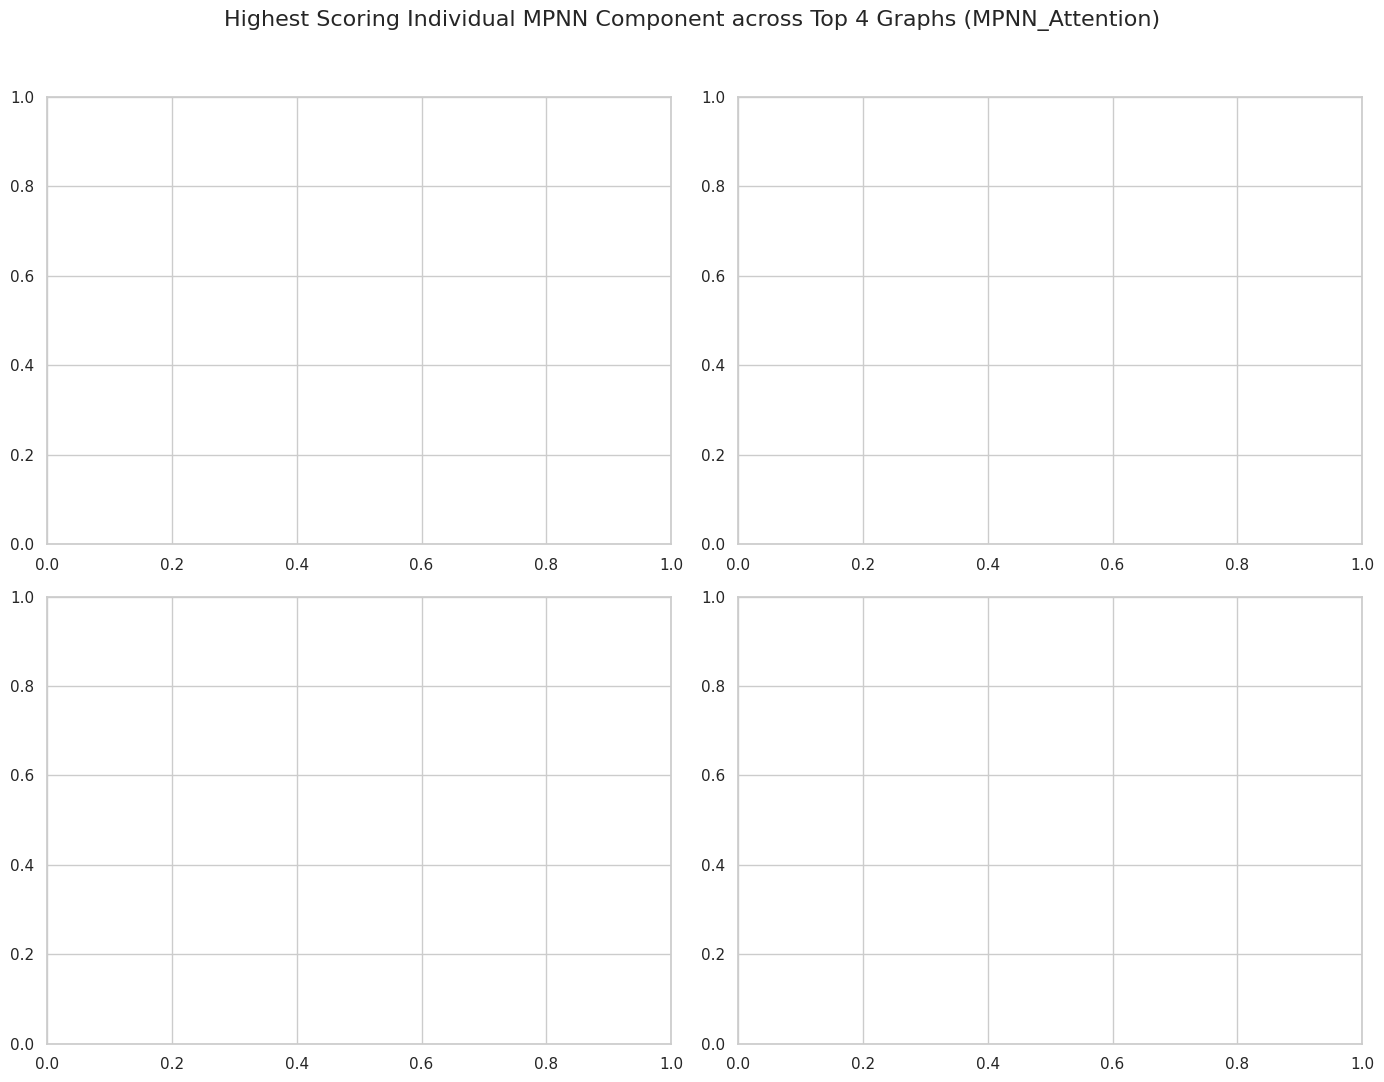

In [10]:
# %%
if 'MPNN_Attention' in data and data['MPNN_Attention']['micro'] and not df_micro.empty:
    # Let's plot the top 4 graphs with the most important structural signals in the MPNN_Attention run
    top_4_indices = df_micro.sort_values(by='max_edge_score', ascending=False).head(4)['graph_index'].values
    
    micro_list_attn = data['MPNN_Attention']['micro']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for ax_idx, g_idx in enumerate(top_4_indices):
        target_data = next(g for g in micro_list_attn if g['graph_index'] == g_idx)
        edge_index = target_data['edge_index'].numpy()
        num_physical_edges = edge_index.shape[1]
        
        # --- Extract the Graph Label ---
        if 'df_labels' in locals():
            label = df_labels.loc[df_labels['graph_index'] == g_idx, 'label'].iloc[0]
        else:
            # Fallback: check if it's saved inside the micro_scores data directly
            y_val = target_data.get('y', target_data.get('label', 'Unknown'))
            if isinstance(y_val, torch.Tensor):
                label = y_val.item() if y_val.numel() == 1 else y_val[0].item()
            else:
                label = y_val
        # ------------------------------------

        # Filter for ONLY local MPNN structural messages (1D tensors)
        m_components = {
            k: v for k, v in target_data['micro_scores'].items() 
            if k.endswith('.M') and v.shape == (num_physical_edges,)
        }
        
        if m_components:
            # --- NEW: Find the SINGLE component with the highest peak score ---
            best_comp_name = max(m_components.keys(), key=lambda k: m_components[k].max().item())
            edge_weights = m_components[best_comp_name].numpy()
            # ----------------------------------------------------------------
            
            # Normalize weights for plotting
            edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)
            
            # Build NetworkX Graph
            G = nx.Graph() 
            for i in range(num_physical_edges):
                src, dst = edge_index[0, i], edge_index[1, i]
                if G.has_edge(src, dst):
                    G[src][dst]['weight'] = max(G[src][dst]['weight'], edge_weights_norm[i])
                else:
                    G.add_edge(src, dst, weight=edge_weights_norm[i])
                    
            edges = G.edges(data=True)
            # Make the most important edges even thicker to stand out
            weights = [d['weight'] * 6 for u, v, d in edges] 
            colors = [d['weight'] for u, v, d in edges]
            
            # Use spring_layout with high 'k' to push nodes apart
            pos = nx.spring_layout(G, k=0.5, iterations=200, seed=42)
            
            nx.draw_networkx_nodes(G, pos, ax=axes[ax_idx], node_size=80, node_color='lightgreen', edgecolors='black')
            
            edges_drawn = nx.draw_networkx_edges(
                G, pos, ax=axes[ax_idx],
                width=weights, 
                edge_color=colors, 
                edge_cmap=plt.cm.magma_r, 
                alpha=0.8
            )
            
            # CHANGED: Show the winning component name and its true raw score in the title
            axes[ax_idx].set_title(f"Graph {g_idx} - Class {label}\nBest Comp: {best_comp_name}\n(Max Score: {edge_weights.max():.4f})", fontsize=11)
            axes[ax_idx].axis("off")
            
            # Add a single colorbar for all subplots based on the first plot
            if ax_idx == 0:
                cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
                fig.colorbar(edges_drawn, cax=cbar_ax, orientation='horizontal', label="Micro-EAP Edge Importance (Normalized)")

    fig.suptitle("Highest Scoring Individual MPNN Component across Top 4 Graphs (MPNN_Attention)", fontsize=16)
    # Adjust layout to make room for colorbar at the bottom
    plt.tight_layout(rect=[0, 0.08, 1, 0.96]) 
    plt.show()
else:
    print("Could not generate plots. Missing MPNN_Attention data.")

In [11]:
import yaml
from src.interpretability.counterfactuals.factory import get_counterfactual_dataset

with open("./config/eap/zinc/graphformer_ba_mpnn_attention.yaml", "r") as f:
    config = yaml.safe_load(f)


#config['dataset']['counterfactual_path'] = "./data/zincs/counterfactuals.pt"
cf_data_list = get_counterfactual_dataset(config, base_dataset=None)

train_cf_list = [
    cf_pair for cf_pair in cf_data_list
    if hasattr(cf_pair['clean'], 'split_mask') and cf_pair['clean'].split_mask.item() == 0
]

print(f"Loaded {len(train_cf_list)} training graphs.")

[Counterfactuals] Found existing file at ./data/zinc_no2/counterfactuals.pt. Loading from disk...
Loaded 358 training graphs.


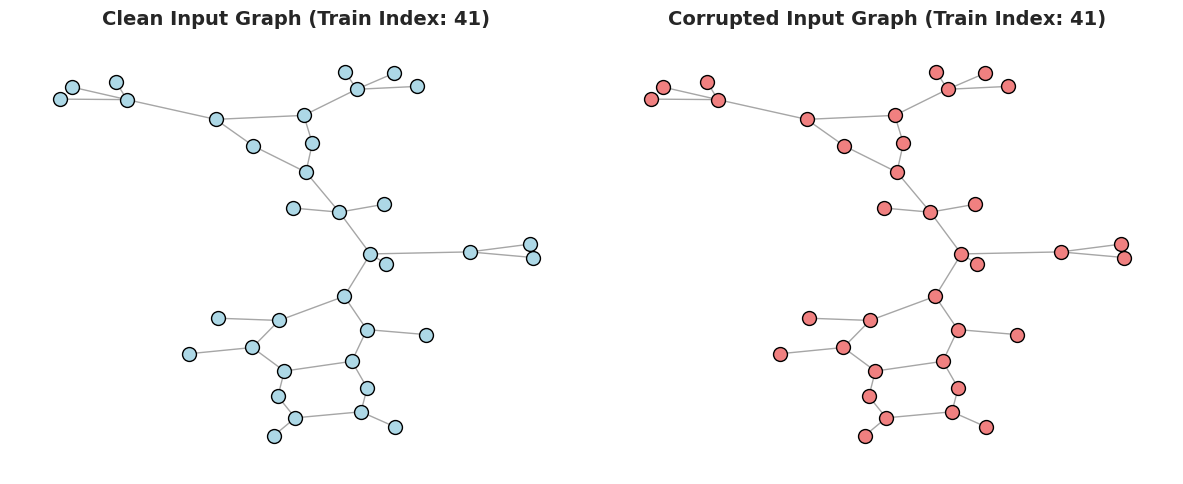

No 'layers.X.conv.M' components found to plot.


In [12]:
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from torch_geometric.utils import to_networkx

if 'MPNN_Attention' in data and data['MPNN_Attention']['micro'] and not df_micro.empty:
    # 1. Pick the absolute top graph
    top_g_idx = int(df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index'])
    
    # 2. Fetch directly from the FILTERED train dataset!
    sample = train_cf_list[top_g_idx]
    clean_data = sample['clean']
    corrupted_data = sample['corrupted']

    # --- 3. PLOT CLEAN VS CORRUPTED SIDE-BY-SIDE ---
    G_clean = to_networkx(clean_data, to_undirected=True)
    G_corr = to_networkx(corrupted_data, to_undirected=True)

    # Generate a shared layout based on the clean graph
    pos_static = nx.spring_layout(G_clean, k=0.5, iterations=200, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Draw Clean Graph
    nx.draw_networkx_nodes(G_clean, pos_static, ax=axes[0], node_size=100, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G_clean, pos_static, ax=axes[0], alpha=0.7, edge_color='gray')
    axes[0].set_title(f"Clean Input Graph (Train Index: {top_g_idx})", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Draw Corrupted Graph
    nx.draw_networkx_nodes(G_corr, pos_static, ax=axes[1], node_size=100, node_color='lightcoral', edgecolors='black')
    nx.draw_networkx_edges(G_corr, pos_static, ax=axes[1], alpha=0.7, edge_color='gray')
    axes[1].set_title(f"Corrupted Input Graph (Train Index: {top_g_idx})", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 4. CONTINUE WITH YOUR ANIMATION CODE ---
    micro_list_attn = data['MPNN_Attention']['micro']
    target_data = next(g for g in micro_list_attn if g['graph_index'] == top_g_idx)
    
    edge_index = target_data['edge_index'].numpy()
    num_physical_edges = edge_index.shape[1]
    
    layer_pattern = re.compile(r'layers\.(\d+)\.conv\.M')
    
    layer_scores = {}
    for k, v in target_data['micro_scores'].items():
        match = layer_pattern.match(k)
        if match and v.shape == (num_physical_edges,):
            layer_idx = int(match.group(1))
            layer_scores[layer_idx] = v.numpy()
            
    if not layer_scores:
        print("No 'layers.X.conv.M' components found to plot.")
    else:
        sorted_layers = sorted(layer_scores.keys())
        num_layers = len(sorted_layers)
        
        all_scores = np.concatenate(list(layer_scores.values()))
        global_min = all_scores.min()
        global_max = all_scores.max()
        
        print(f"Generating Interactive Animation for Graph {top_g_idx} across {num_layers} layers...")
        
        fig, ax = plt.subplots(figsize=(7, 7))
        sm = plt.cm.ScalarMappable(cmap=plt.cm.magma_r, norm=plt.Normalize(vmin=0, vmax=1))
        sm._A = []  
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
        cbar.set_label("Micro-EAP Edge Importance (Globally Normalized)")

        G_base = nx.Graph()
        for i in range(num_physical_edges):
            G_base.add_edge(edge_index[0, i], edge_index[1, i])
            
        pos = pos_static 
        
        def update(frame):
            ax.clear()
            l_idx = sorted_layers[frame]
            raw_weights = layer_scores[l_idx]
            norm_weights = (raw_weights - global_min) / (global_max - global_min + 1e-8)
            
            for u, v in G_base.edges():
                G_base[u][v]['weight'] = 0.0
                
            for i, (u, v) in enumerate(zip(edge_index[0], edge_index[1])):
                if G_base.has_edge(u, v):
                    current_weight = G_base[u][v].get('weight', 0.0)
                    G_base[u][v]['weight'] = max(current_weight, norm_weights[i])
            
            edges = G_base.edges(data=True)
            weights = [d['weight'] * 6 for u, v, d in edges]
            colors = [d['weight'] for u, v, d in edges]
            
            nx.draw_networkx_nodes(G_base, pos, ax=ax, node_size=80, node_color='lightgreen', edgecolors='black')
            nx.draw_networkx_edges(
                G_base, pos, ax=ax,
                width=weights, edge_color=colors, edge_cmap=plt.cm.magma_r, 
                edge_vmin=0.0, edge_vmax=1.0, alpha=0.8
            )
            
            ax.set_title(f"Information Routing: Graph {top_g_idx}\nLayer {l_idx} (Local Max Score: {raw_weights.max():.4f})", fontsize=14)
            ax.axis("off")
            
        anim = FuncAnimation(fig, update, frames=num_layers, interval=1000, repeat=False)
        plt.close(fig)
        display(HTML(anim.to_jshtml()))
else:
    print("Could not generate animation. Missing MPNN_Attention data.")

In [13]:
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from torch_geometric.utils import to_networkx

if 'MPNN' in data and data['MPNN']['micro'] and not df_micro.empty:
    top_g_idx = int(df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index'])
    
    sample = train_cf_list[top_g_idx]
    clean_data = sample['clean']
    corrupted_data = sample['corrupted']

    G_clean = to_networkx(clean_data, to_undirected=True)
    G_corr = to_networkx(corrupted_data, to_undirected=True)

    pos_static = nx.spring_layout(G_clean, k=0.5, iterations=200, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    nx.draw_networkx_nodes(G_clean, pos_static, ax=axes[0], node_size=100, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G_clean, pos_static, ax=axes[0], alpha=0.7, edge_color='gray')
    axes[0].set_title(f"Clean Input Graph (Train Index: {top_g_idx})", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    nx.draw_networkx_nodes(G_corr, pos_static, ax=axes[1], node_size=100, node_color='lightcoral', edgecolors='black')
    nx.draw_networkx_edges(G_corr, pos_static, ax=axes[1], alpha=0.7, edge_color='gray')
    axes[1].set_title(f"Corrupted Input Graph (Train Index: {top_g_idx})", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    run_data = data['MPNN']
    masks = run_data.get('masks', {})
    micro_list = run_data['micro']
    target_data = next(g for g in micro_list if g['graph_index'] == top_g_idx)
    
    edge_index = target_data['edge_index'].numpy()
    num_physical_edges = edge_index.shape[1]
    
    layer_pattern = re.compile(r'layers\.(\d+)\.conv\.M')
    
    layer_scores = {}
    layer_active_status = {}
    
    for k, v in target_data['micro_scores'].items():
        match = layer_pattern.match(k)
        if match and v.shape == (num_physical_edges,):
            layer_idx = int(match.group(1))
            
            mask_val = masks.get(k, 0)
            is_active = (mask_val > 0).any().item() if isinstance(mask_val, torch.Tensor) else mask_val > 0
            
            layer_active_status[layer_idx] = is_active
            
            if is_active:
                layer_scores[layer_idx] = v.numpy()
            else:
                layer_scores[layer_idx] = np.zeros(num_physical_edges)
            
    if not layer_scores:
        print("No 'layers.X.conv.M' components found to plot.")
    else:
        sorted_layers = sorted(layer_scores.keys())
        num_layers = len(sorted_layers)
        print(f"Scored for: {num_layers}")
        
        all_scores = np.concatenate(list(layer_scores.values()))
        global_min = all_scores.min()
        global_max = all_scores.max()
        
        fig, ax = plt.subplots(figsize=(7, 7))
        sm = plt.cm.ScalarMappable(cmap=plt.cm.magma_r, norm=plt.Normalize(vmin=0, vmax=1))
        sm._A = []  
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
        cbar.set_label("Micro-EAP Edge Importance (Globally Normalized)")

        G_base = nx.Graph()
        for i in range(num_physical_edges):
            G_base.add_edge(edge_index[0, i], edge_index[1, i])
            
        pos = pos_static 
        
        def update(frame):
            ax.clear()
            l_idx = sorted_layers[frame]
            raw_weights = layer_scores[l_idx]
            is_active = layer_active_status[l_idx]
            
            if global_max > global_min:
                norm_weights = (raw_weights - global_min) / (global_max - global_min + 1e-8)
            else:
                norm_weights = raw_weights
            
            for u, v in G_base.edges():
                G_base[u][v]['weight'] = 0.0
                
            for i, (u, v) in enumerate(zip(edge_index[0], edge_index[1])):
                if G_base.has_edge(u, v):
                    current_weight = G_base[u][v].get('weight', 0.0)
                    G_base[u][v]['weight'] = max(current_weight, norm_weights[i])
            
            edges = G_base.edges(data=True)
            weights = [d['weight'] * 6 for u, v, d in edges]
            colors = [d['weight'] for u, v, d in edges]
            
            nx.draw_networkx_nodes(G_base, pos, ax=ax, node_size=80, node_color='lightgreen', edgecolors='black')
            nx.draw_networkx_edges(
                G_base, pos, ax=ax,
                width=weights, edge_color=colors, edge_cmap=plt.cm.magma_r, 
                edge_vmin=0.0, edge_vmax=1.0, alpha=0.8
            )
            
            if is_active:
                ax.set_title(f"Information Routing: Graph {top_g_idx}\nLayer {l_idx} (Local Max Score: {raw_weights.max():.4f})", fontsize=14)
            else:
                ax.set_title(f"Information Routing: Graph {top_g_idx}\nLayer {l_idx} (PRUNED)", fontsize=14, color='red')
            ax.axis("off")
            
        anim = FuncAnimation(fig, update, frames=num_layers, interval=1000, repeat=False)
        plt.close(fig)
        display(HTML(anim.to_jshtml()))
else:
    print("Could not generate animation. Missing MPNN data.")

Could not generate animation. Missing MPNN data.


In [14]:
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from torch_geometric.utils import to_networkx

if 'MPNN' in data and data['MPNN']['micro'] and not df_micro.empty:
    top_g_idx = int(df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index'])
    
    sample = train_cf_list[top_g_idx]
    clean_data = sample['clean']
    corrupted_data = sample['corrupted']

    G_clean = to_networkx(clean_data, to_undirected=True)
    G_corr = to_networkx(corrupted_data, to_undirected=True)

    pos_static = nx.spring_layout(G_clean, k=0.5, iterations=200, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    nx.draw_networkx_nodes(G_clean, pos_static, ax=axes[0], node_size=100, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G_clean, pos_static, ax=axes[0], alpha=0.7, edge_color='gray')
    axes[0].set_title(f"Clean Input Graph (Train Index: {top_g_idx})", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    nx.draw_networkx_nodes(G_corr, pos_static, ax=axes[1], node_size=100, node_color='lightcoral', edgecolors='black')
    nx.draw_networkx_edges(G_corr, pos_static, ax=axes[1], alpha=0.7, edge_color='gray')
    axes[1].set_title(f"Corrupted Input Graph (Train Index: {top_g_idx})", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    run_data = data['MPNN']
    masks = run_data.get('masks', {})
    micro_list = run_data['micro']
    target_data = next(g for g in micro_list if g['graph_index'] == top_g_idx)
    
    edge_index = target_data['edge_index'].numpy()
    num_physical_edges = edge_index.shape[1]
    
    layer_pattern = re.compile(r'layers\.(\d+)\.conv\.M')
    
    layer_scores = {}
    layer_active_status = {}
    
    for k, v in target_data['micro_scores'].items():
        match = layer_pattern.match(k)
        if match and v.shape == (num_physical_edges,):
            layer_idx = int(match.group(1))
            
            mask_val = masks.get(k, 0)
            is_active = (mask_val > 0).any().item() if isinstance(mask_val, torch.Tensor) else mask_val > 0
            
            layer_active_status[layer_idx] = is_active
            
            if is_active:
                layer_scores[layer_idx] = v.numpy()
            else:
                layer_scores[layer_idx] = np.zeros(num_physical_edges)
            
    if not layer_scores:
        print("No 'layers.X.conv.M' components found to plot.")
    else:
        sorted_layers = sorted(layer_scores.keys())
        num_layers = len(sorted_layers)
        print(f"Scored for: {num_layers}")
        
        all_scores = np.concatenate(list(layer_scores.values()))
        global_min = all_scores.min()
        global_max = all_scores.max()
        
        fig, ax = plt.subplots(figsize=(7, 7))
        sm = plt.cm.ScalarMappable(cmap=plt.cm.magma_r, norm=plt.Normalize(vmin=0, vmax=1))
        sm._A = []  
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
        cbar.set_label("Micro-EAP Edge Importance (Globally Normalized)")

        G_base = nx.Graph()
        for i in range(num_physical_edges):
            u, v = edge_index[0, i], edge_index[1, i]
            if u != v: 
                G_base.add_edge(u, v)
            
        pos = pos_static 
        
        def update(frame):
            ax.clear()
            l_idx = sorted_layers[frame]
            raw_weights = layer_scores[l_idx]
            is_active = layer_active_status[l_idx]
            
            if global_max > global_min:
                norm_weights = (raw_weights - global_min) / (global_max - global_min + 1e-8)
            else:
                norm_weights = raw_weights
            
            nx.draw_networkx_edges(G_clean, pos_static, ax=ax, edge_color='lightgray', alpha=0.4, width=1.5)
            
            for u, v in G_base.edges():
                G_base[u][v]['weight'] = 0.0
                
            for i, (u, v) in enumerate(zip(edge_index[0], edge_index[1])):
                if u != v and G_base.has_edge(u, v):
                    current_weight = G_base[u][v].get('weight', 0.0)
                    G_base[u][v]['weight'] = max(current_weight, norm_weights[i])
            
            edges = G_base.edges(data=True)
            weights = [d['weight'] * 6 for u, v, d in edges]
            colors = [d['weight'] for u, v, d in edges]
            
            nx.draw_networkx_nodes(G_base, pos, ax=ax, node_size=80, node_color='lightgreen', edgecolors='black')
            nx.draw_networkx_edges(
                G_base, pos, ax=ax,
                width=weights, edge_color=colors, edge_cmap=plt.cm.magma_r, 
                edge_vmin=0.0, edge_vmax=1.0, alpha=0.8
            )
            
            if is_active:
                ax.set_title(f"Information Routing: Graph {top_g_idx}\nLayer {l_idx} (Local Max Score: {raw_weights.max():.4f})", fontsize=14)
            else:
                ax.set_title(f"Information Routing: Graph {top_g_idx}\nLayer {l_idx} (PRUNED)", fontsize=14, color='red')
            ax.axis("off")
            
        anim = FuncAnimation(fig, update, frames=num_layers, interval=1000, repeat=False)
        plt.close(fig)
        display(HTML(anim.to_jshtml()))
else:
    print("Could not generate animation. Missing MPNN data.")

Could not generate animation. Missing MPNN data.


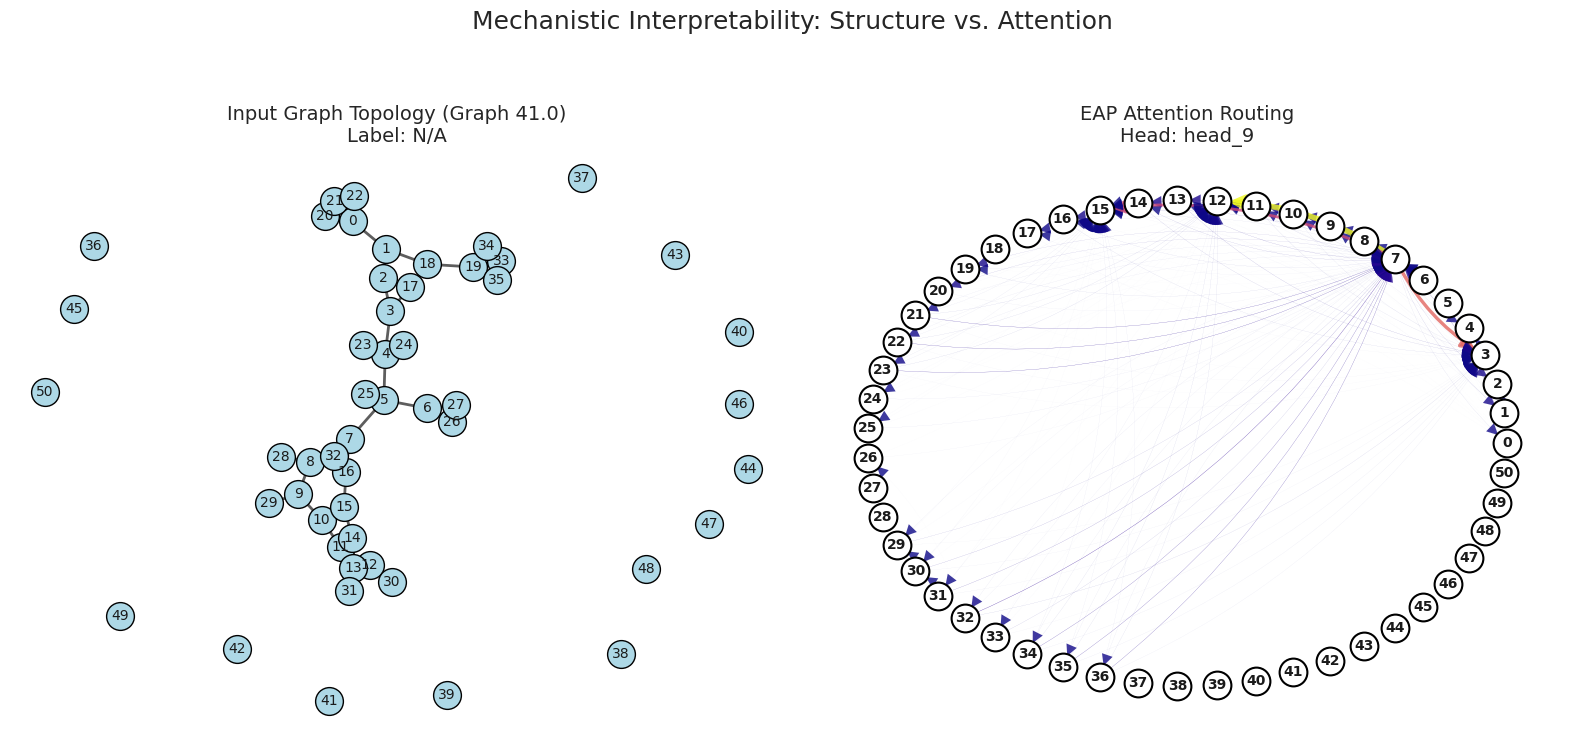

In [15]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

# %%
# Select the single highest-scoring graph for a clear "One Row" view
if 'MPNN_Attention' in data and not df_micro.empty:
    top_g_idx = df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index']
    micro_list_attn = data['MPNN_Attention']['micro']
    target_data = next(g for g in micro_list_attn if g['graph_index'] == top_g_idx)
    
    # --- 1. Data Preparation ---
    edge_index = target_data['edge_index'].numpy()
    label = target_data.get('y', 'N/A')
    
    # Extract the best attention head (using the keys generated in run_eap.py)
    attn_heads = {k: v for k, v in target_data['micro_scores'].items() if 'head' in k}
    best_head_key = max(attn_heads.keys(), key=lambda k: attn_heads[k].max().item())
    attn_matrix = attn_heads[best_head_key].numpy()
    num_nodes = attn_matrix.shape[0]

    # Create the Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # ---------------------------------------------------------
    # LEFT PLOT: THE PHYSICAL GRAPH (Input Structure)
    # ---------------------------------------------------------
    G_phys = nx.Graph()
    G_phys.add_nodes_from(range(num_nodes))
    for i in range(edge_index.shape[1]):
        G_phys.add_edge(edge_index[0, i], edge_index[1, i])
    
    # Spring layout shows the molecular/physical shape
    pos_phys = nx.spring_layout(G_phys, seed=42)
    
    nx.draw_networkx_nodes(G_phys, pos_phys, ax=axes[0], node_size=400, 
                           node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G_phys, pos_phys, ax=axes[0], width=2.0, alpha=0.7)
    nx.draw_networkx_labels(G_phys, pos_phys, ax=axes[0], font_size=10)
    
    axes[0].set_title(f"Input Graph Topology (Graph {top_g_idx})\nLabel: {label}", fontsize=14)
    axes[0].axis("off")

    # ---------------------------------------------------------
    # RIGHT PLOT: THE ATTENTION EAP (Model Interpretation)
    # ---------------------------------------------------------
    G_attn = nx.DiGraph()
    G_attn.add_nodes_from(range(num_nodes))
    
    # Threshold to show top 10% of routing connections
    threshold = np.percentile(attn_matrix[attn_matrix > 0], 90) if attn_matrix.any() else 0
    
    for u in range(num_nodes):
        for v in range(num_nodes):
            weight = attn_matrix[u, v].item()
            if weight > threshold:
                G_attn.add_edge(u, v, weight=weight)
    
    # Circular layout makes it clear how information flows between nodes
    pos_attn = nx.circular_layout(G_attn)
    
    # Draw nodes and labels
    nx.draw_networkx_nodes(G_attn, pos_attn, ax=axes[1], node_size=400, 
                           node_color='white', edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G_attn, pos_attn, ax=axes[1], font_size=10, font_weight='bold')
    
    # Draw edges with Plasma colormap (Yellow = High Attribution)
    weights = [G_attn[u][v]['weight'] for u, v in G_attn.edges()]
    if weights:
        max_w = max(weights)
        edge_colors = [plt.cm.plasma(w / max_w) for w in weights]
        
        nx.draw_networkx_edges(
            G_attn, pos_attn, ax=axes[1],
            width=[(w/max_w)*4 for w in weights],
            edge_color=edge_colors,
            connectionstyle="arc3,rad=0.15", # Curved for bidirectional visibility
            arrowsize=20,
            alpha=0.8
        )

    axes[1].set_title(f"EAP Attention Routing\nHead: {best_head_key.split('.')[-1]}", fontsize=14)
    axes[1].axis("off")

    plt.suptitle(f"Mechanistic Interpretability: Structure vs. Attention", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

Total potential attention components found: 384
Final Count: 288/384 heads active.


/tmp/ipykernel_36275/3917953483.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


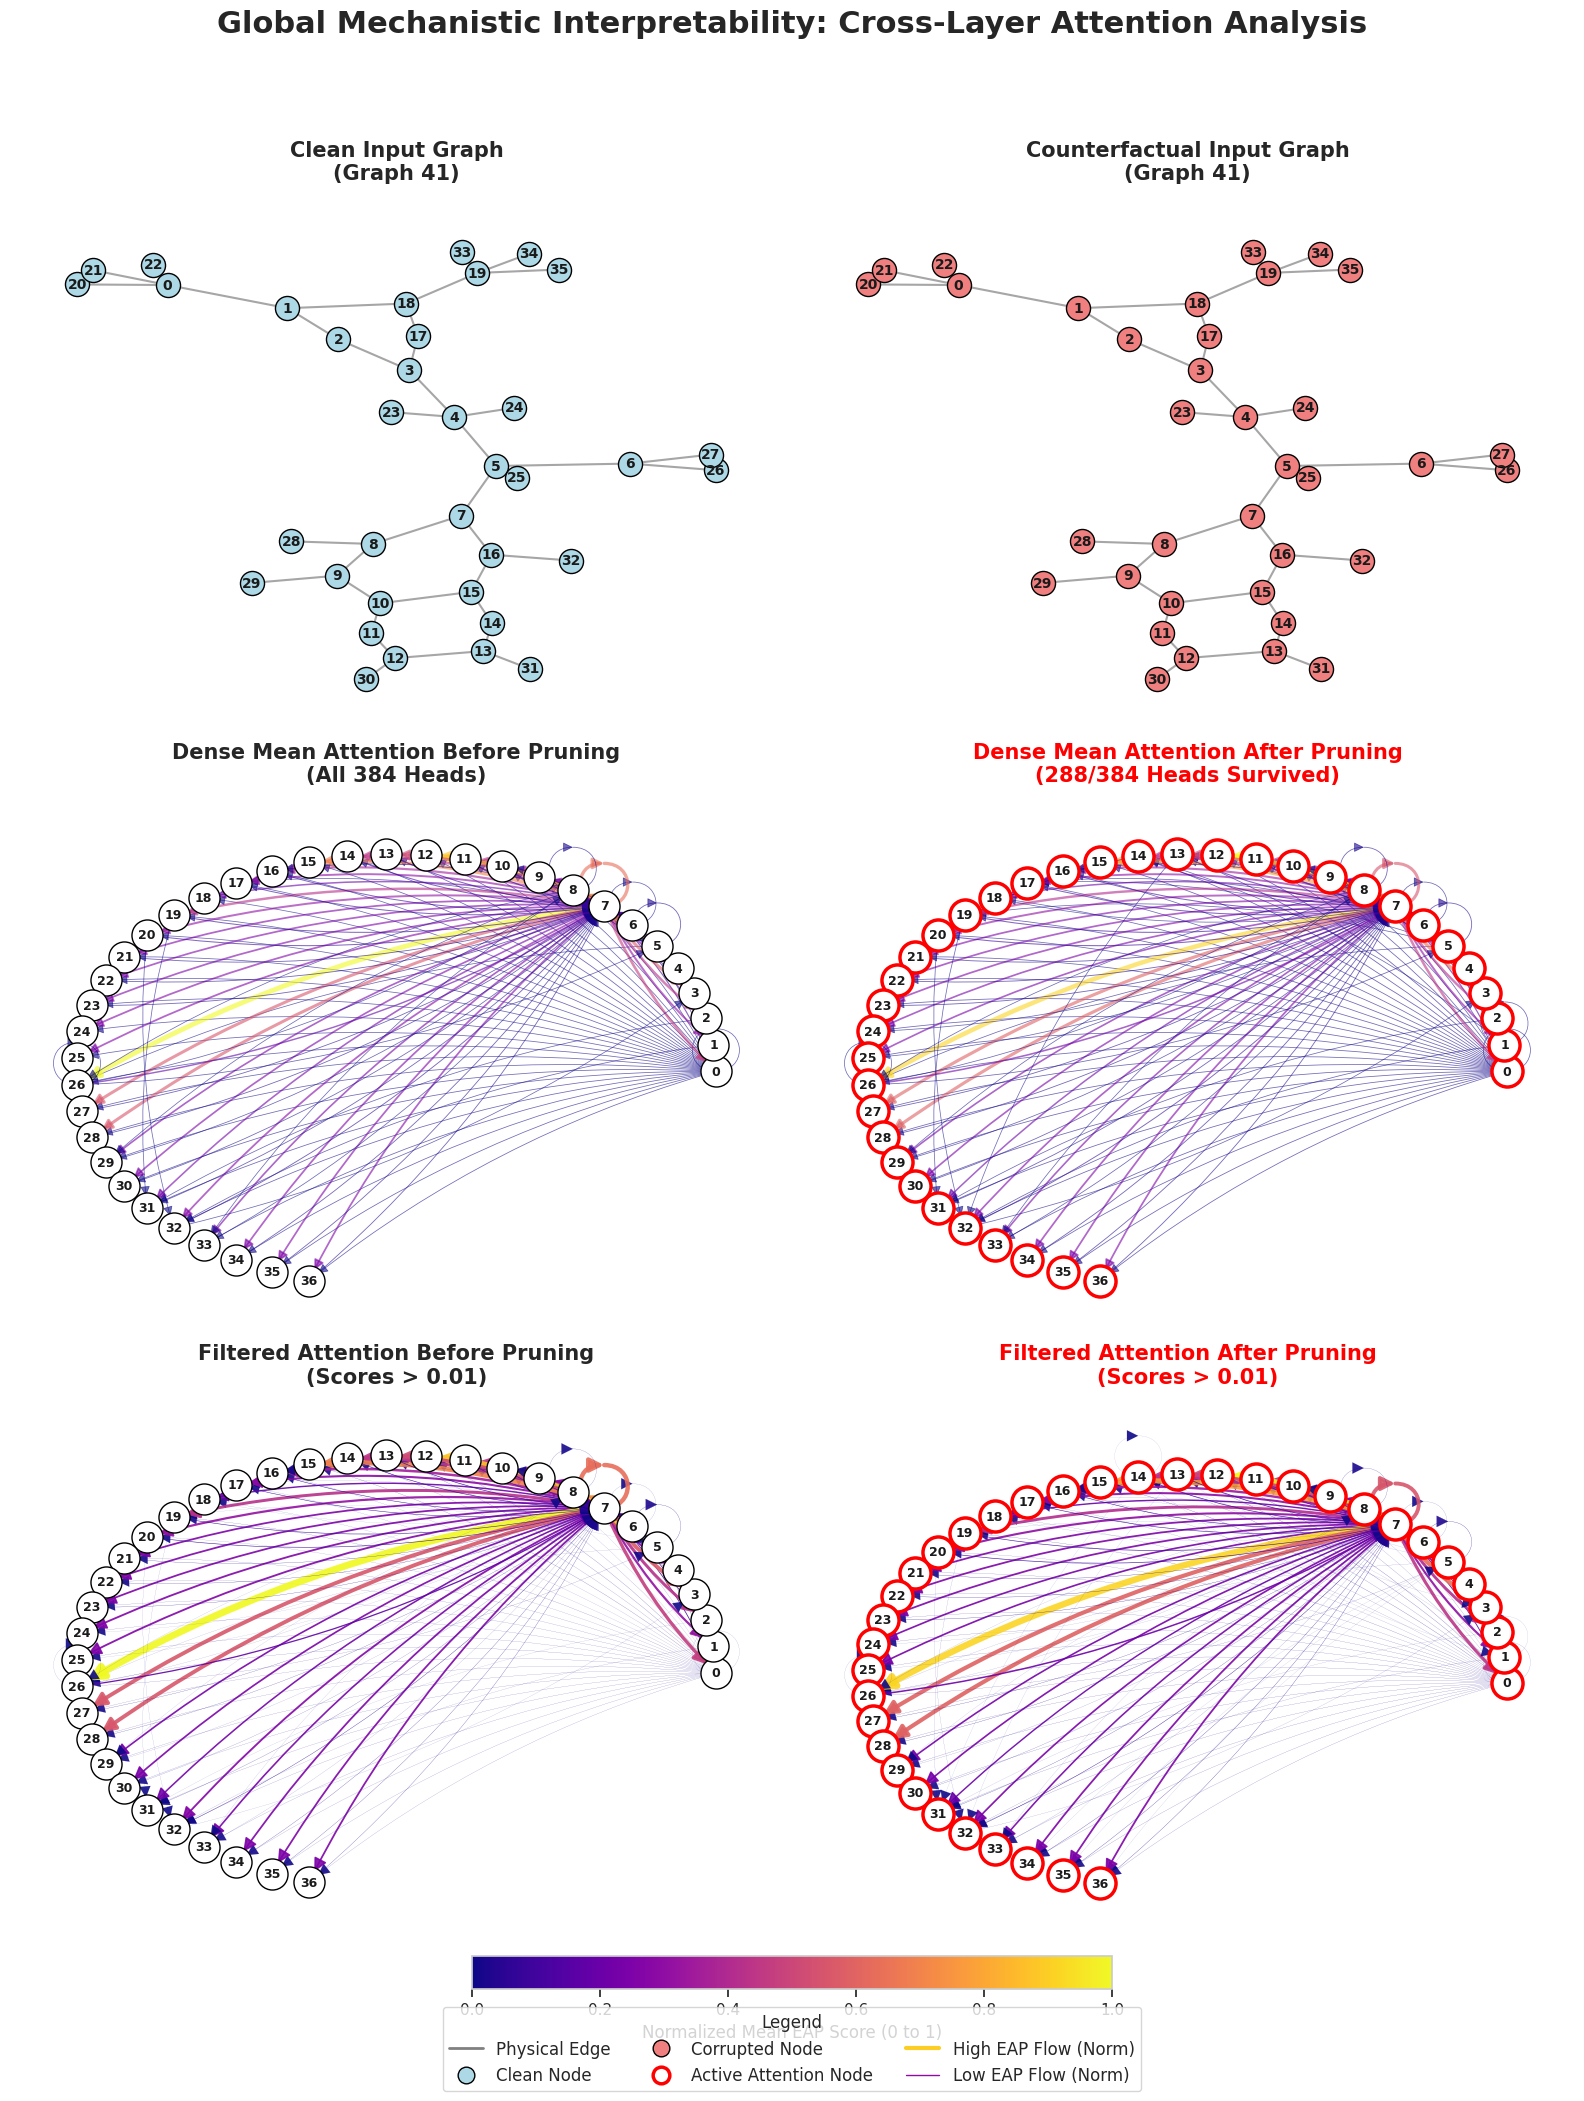

In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from matplotlib.lines import Line2D
from torch_geometric.utils import to_networkx

RUN_NAME = 'MPNN_Attention'

if RUN_NAME in data and not df_micro.empty:
    top_g_idx = int(df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index'])
    run_data = data[RUN_NAME]
    target_data = next(g for g in run_data['micro'] if g['graph_index'] == top_g_idx)
    masks = run_data.get('masks', {})
    
    sample = train_cf_list[top_g_idx]
    clean_data = sample['clean']
    corrupted_data = sample['corrupted']

    G_clean = to_networkx(clean_data, to_undirected=True)
    G_corr = to_networkx(corrupted_data, to_undirected=True)
    
    all_head_tensors = []
    active_head_tensors = []
    
    # --- UPDATED KEY SELECTION ---
    # In 'Classic', we look for 'head'. 
    # In 'MPNN_Attention', the attention flow is captured in the '.M' (Message) component.
    # --- UPDATED DEBUGGING & SELECTION ---
    head_keys = [k for k in target_data['micro_scores'].keys() if 'head' in k or k.endswith('.M')]
    
    print(f"Total potential attention components found: {len(head_keys)}")

    for k in head_keys:
        attn_matrix = target_data['micro_scores'][k].numpy()
        if attn_matrix.ndim == 3:
            attn_matrix = np.mean(attn_matrix, axis=0)
        
        all_head_tensors.append(attn_matrix)
        
        # --- NEW ROBUST MASK CHECK ---
        # 1. Check if the exact key exists (e.g., ...M.head_0)
        # 2. If not, check if the parent module key exists (e.g., ...M)
        mask_val = masks.get(k, None)
        if mask_val is None and '.head_' in k:
            parent_key = k.split('.head_')[0]
            mask_val = masks.get(parent_key, 0)
        elif mask_val is None:
            mask_val = 0
            
        is_active = (mask_val > 0).any().item() if isinstance(mask_val, torch.Tensor) else mask_val > 0
        
        if is_active:
            active_head_tensors.append(attn_matrix)

    print(f"Final Count: {len(active_head_tensors)}/{len(all_head_tensors)} heads active.")

    mean_all = np.mean(all_head_tensors, axis=0) if all_head_tensors else np.zeros((20, 20))
    mean_active = np.mean(active_head_tensors, axis=0) if active_head_tensors else np.zeros_like(mean_all)
    num_nodes = mean_all.shape[0]

    def normalize_matrix(mat):
        m_min, m_max = mat.min(), mat.max()
        if m_max - m_min > 1e-9:
            return (mat - m_min) / (m_max - m_min)
        return mat

    norm_all = normalize_matrix(mean_all)
    norm_active = normalize_matrix(mean_active)

    # Expanded to 3 rows
    fig, axes = plt.subplots(3, 2, figsize=(16, 22))
    pos_static = nx.spring_layout(G_clean, k=0.5, iterations=200, seed=42)
    pos_circ = nx.circular_layout(range(num_nodes))
    cmap = plt.cm.plasma

    # ==========================================
    # ROW 1: INPUT GRAPHS
    # ==========================================
    nx.draw_networkx_nodes(G_clean, pos_static, ax=axes[0, 0], node_size=300, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_labels(G_clean, pos_static, ax=axes[0, 0], font_size=10, font_weight='bold')
    nx.draw_networkx_edges(G_clean, pos_static, ax=axes[0, 0], width=1.5, alpha=0.7, edge_color='gray')
    axes[0, 0].set_title(f"Clean Input Graph\n(Graph {top_g_idx})", fontsize=15, fontweight='bold', pad=20)
    axes[0, 0].axis('off')

    nx.draw_networkx_nodes(G_corr, pos_static, ax=axes[0, 1], node_size=300, node_color='lightcoral', edgecolors='black')
    nx.draw_networkx_labels(G_corr, pos_static, ax=axes[0, 1], font_size=10, font_weight='bold')
    nx.draw_networkx_edges(G_corr, pos_static, ax=axes[0, 1], width=1.5, alpha=0.7, edge_color='gray')
    axes[0, 1].set_title(f"Counterfactual Input Graph\n(Graph {top_g_idx})", fontsize=15, fontweight='bold', pad=20)
    axes[0, 1].axis('off')

    # ==========================================
    # ROW 2: DENSE ATTENTION (NO THRESHOLD)
    # ==========================================
    G_all_dense = nx.DiGraph()
    for u in range(num_nodes):
        for v in range(num_nodes):
            if norm_all[u,v] > 0.01: # Minimal non-zero check to avoid drawing literal 0s
                G_all_dense.add_edge(u, v, weight=norm_all[u,v])
    
    nx.draw_networkx_nodes(G_all_dense, pos_circ, ax=axes[1, 0], node_size=500, node_color='white', edgecolors='black')
    nx.draw_networkx_labels(G_all_dense, pos_circ, ax=axes[1, 0], font_size=9, font_weight='bold')
    weights_all_dense = [G_all_dense[u][v]['weight'] for u, v in G_all_dense.edges()]
    if weights_all_dense:
        nx.draw_networkx_edges(G_all_dense, pos_circ, ax=axes[1, 0], edge_color=weights_all_dense, 
                               edge_cmap=cmap, width=[0.5 + w*3 for w in weights_all_dense], 
                               connectionstyle="arc3,rad=0.1", arrowsize=15, alpha=0.6)
    axes[1, 0].set_title(f"Dense Mean Attention Before Pruning\n(All {len(all_head_tensors)} Heads)", fontsize=15, fontweight='bold', pad=20)
    axes[1, 0].axis('off')

    G_act_dense = nx.DiGraph()
    if norm_active.any():
        for u in range(num_nodes):
            for v in range(num_nodes):
                if norm_active[u,v] > 0.01: 
                    G_act_dense.add_edge(u, v, weight=norm_active[u,v])
    
    nx.draw_networkx_nodes(G_act_dense, pos_circ, ax=axes[1, 1], node_size=500, node_color='white', edgecolors='red', linewidths=2.5)
    nx.draw_networkx_labels(G_act_dense, pos_circ, ax=axes[1, 1], font_size=9, font_weight='bold')
    weights_act_dense = [G_act_dense[u][v]['weight'] for u, v in G_act_dense.edges()]
    if weights_act_dense:
        nx.draw_networkx_edges(G_act_dense, pos_circ, ax=axes[1, 1], edge_color=weights_act_dense, 
                               edge_cmap=cmap, width=[0.5 + w*3 for w in weights_act_dense], 
                               connectionstyle="arc3,rad=0.1", arrowsize=15, alpha=0.6)
    
    survivors = f"{len(active_head_tensors)}/{len(all_head_tensors)}"
    axes[1, 1].set_title(f"Dense Mean Attention After Pruning\n({survivors} Heads Survived)", fontsize=15, fontweight='bold', color='red', pad=20)
    axes[1, 1].axis('off')

    # ==========================================
    # ROW 3: THRESHOLDED ATTENTION (VISUAL MINIMUM)
    # ==========================================
    # We set a minimal visual threshold (e.g. 90th percentile) to highlight ONLY main pathways
    VISUAL_THRESHOLD = np.percentile(norm_all, 95) 
    
    G_all_thresh = nx.DiGraph()
    for u in range(num_nodes):
        for v in range(num_nodes):
            if norm_all[u,v] > VISUAL_THRESHOLD: 
                G_all_thresh.add_edge(u, v, weight=norm_all[u,v])
    
    nx.draw_networkx_nodes(G_all_thresh, pos_circ, ax=axes[2, 0], node_size=500, node_color='white', edgecolors='black')
    nx.draw_networkx_labels(G_all_thresh, pos_circ, ax=axes[2, 0], font_size=9, font_weight='bold')
    weights_all_thresh = [G_all_thresh[u][v]['weight'] for u, v in G_all_thresh.edges()]
    if weights_all_thresh:
        nx.draw_networkx_edges(G_all_thresh, pos_circ, ax=axes[2, 0], edge_color=weights_all_thresh, 
                               edge_cmap=cmap, width=[w*5 for w in weights_all_thresh], 
                               connectionstyle="arc3,rad=0.1", arrowsize=20, alpha=0.9)
    axes[2, 0].set_title(f"Filtered Attention Before Pruning\n(Scores > {VISUAL_THRESHOLD:.2f})", fontsize=15, fontweight='bold', pad=20)
    axes[2, 0].axis('off')

    G_act_thresh = nx.DiGraph()
    if norm_active.any():
        for u in range(num_nodes):
            for v in range(num_nodes):
                if norm_active[u,v] > VISUAL_THRESHOLD: 
                    G_act_thresh.add_edge(u, v, weight=norm_active[u,v])
    
    nx.draw_networkx_nodes(G_act_thresh, pos_circ, ax=axes[2, 1], node_size=500, node_color='white', edgecolors='red', linewidths=2.5)
    nx.draw_networkx_labels(G_act_thresh, pos_circ, ax=axes[2, 1], font_size=9, font_weight='bold')
    weights_act_thresh = [G_act_thresh[u][v]['weight'] for u, v in G_act_thresh.edges()]
    if weights_act_thresh:
        nx.draw_networkx_edges(G_act_thresh, pos_circ, ax=axes[2, 1], edge_color=weights_act_thresh, 
                               edge_cmap=cmap, width=[w*5 for w in weights_act_thresh], 
                               connectionstyle="arc3,rad=0.1", arrowsize=20, alpha=0.9)
    
    axes[2, 1].set_title(f"Filtered Attention After Pruning\n(Scores > {VISUAL_THRESHOLD:.2f})", fontsize=15, fontweight='bold', color='red', pad=20)
    axes[2, 1].axis('off')

    # ==========================================
    # LEGEND & COLORBAR
    # ==========================================
    legend_elements = [
        Line2D([0], [0], color='gray', lw=2, label='Physical Edge'),
        Line2D([0], [0], marker='o', color='w', label='Clean Node', markerfacecolor='lightblue', markersize=12, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label='Corrupted Node', markerfacecolor='lightcoral', markersize=12, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label='Active Attention Node', markerfacecolor='white', markersize=12, markeredgecolor='red', markeredgewidth=2.5),
        Line2D([0], [0], color=cmap(0.9), lw=3, label='High EAP Flow (Norm)'),
        Line2D([0], [0], color=cmap(0.3), lw=1, label='Low EAP Flow (Norm)')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.03), fontsize=12, frameon=True, title="Legend")

    sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap=cmap)
    cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.015])
    fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='Normalized Mean EAP Score (0 to 1)')

    plt.suptitle(f"Global Mechanistic Interpretability: Cross-Layer Attention Analysis", fontsize=22, y=0.98, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.show()

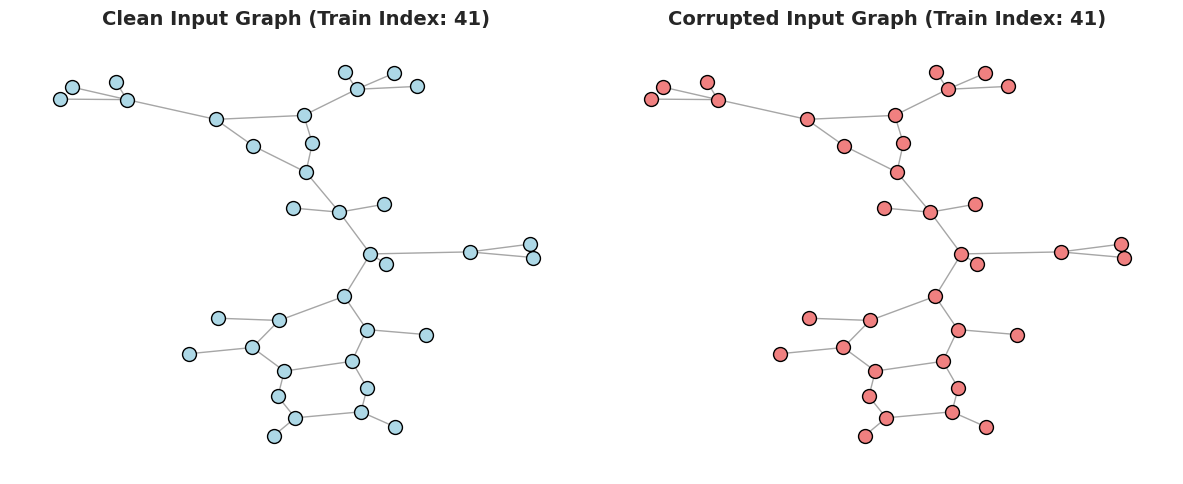

Animating 12 layers. Global Range: 0.0000 to 0.0030


In [18]:
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from collections import defaultdict
from torch_geometric.utils import to_networkx

if 'MPNN_Attention' in data and data['MPNN_Attention']['micro'] and not df_micro.empty:
    # 1. Pick the absolute top graph
    top_g_idx = int(df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index'])
    
    # 2. Fetch directly from the FILTERED train dataset
    sample = train_cf_list[top_g_idx]
    clean_data = sample['clean']
    corrupted_data = sample['corrupted']

    # --- 3. PLOT CLEAN VS CORRUPTED SIDE-BY-SIDE ---
    G_clean = to_networkx(clean_data, to_undirected=True)
    G_corr = to_networkx(corrupted_data, to_undirected=True)
    pos_static = nx.spring_layout(G_clean, k=0.5, iterations=200, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    nx.draw_networkx_nodes(G_clean, pos_static, ax=axes[0], node_size=100, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G_clean, pos_static, ax=axes[0], alpha=0.7, edge_color='gray')
    axes[0].set_title(f"Clean Input Graph (Train Index: {top_g_idx})", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    nx.draw_networkx_nodes(G_corr, pos_static, ax=axes[1], node_size=100, node_color='lightcoral', edgecolors='black')
    nx.draw_networkx_edges(G_corr, pos_static, ax=axes[1], alpha=0.7, edge_color='gray')
    axes[1].set_title(f"Corrupted Input Graph (Train Index: {top_g_idx})", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # --- 4. PREPARE ATTENTION ANIMATION DATA ---
    micro_list_attn = data['MPNN_Attention']['micro']
    target_data = next(g for g in micro_list_attn if g['graph_index'] == top_g_idx)
    num_nodes = clean_data.num_nodes
    
    # --- UPDATED KEY SELECTION ---
    layer_attn_scores = defaultdict(list)
    for k, v in target_data['micro_scores'].items():
        # Change: Look for 'head' OR '.M' (the Message component)
        if 'head' in k or k.endswith('.M'):
            match = re.search(r'layers\.(\d+)', k)
            if match:
                l_idx = int(match.group(1))
                attn_matrix = v.numpy()
                
                # Change: If the matrix is 3D (Multi-head), average it into 2D
                if attn_matrix.ndim == 3:
                    attn_matrix = np.mean(attn_matrix, axis=0)
                    
                layer_attn_scores[l_idx].append(attn_matrix)
                
    if not layer_attn_scores:
        print("No attention components (.M or head) found. Check your wrapper instrumentation.")
    else:
        # Calculate the Mean Attention Matrix per layer
        layer_means = {l_idx: np.mean(mats, axis=0) for l_idx, mats in layer_attn_scores.items()}
        sorted_layers = sorted(layer_means.keys())
        num_layers = len(sorted_layers)
        
        all_means = np.array(list(layer_means.values()))
        global_min, global_max = all_means.min(), all_means.max()
        
        print(f"Animating {num_layers} layers. Global Range: {global_min:.4f} to {global_max:.4f}")
        
        # --- 5. SETUP ANIMATION FIGURE ---
        fig, ax = plt.subplots(figsize=(8, 8))
        cmap = plt.cm.plasma
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
        sm._A = []  
        fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04, label="Normalized Attention Flow")

        # Visual threshold: adjusted to 0.1 to see more "routing"
        VISUAL_THRESHOLD = 0.1
        
        def update(frame):
            ax.clear()
            l_idx = sorted_layers[frame]
            mat = layer_means[l_idx]
            
            # Normalize scores between 0 and 1 for this frame based on global limits
            norm_mat = (mat - global_min) / (global_max - global_min + 1e-8)
            
            nx.draw_networkx_edges(G_clean, pos_static, ax=ax, edge_color='lightgray', alpha=0.3, width=1.0)
            
            G_attn = nx.DiGraph()
            for u in range(num_nodes):
                for v in range(num_nodes):
                    if norm_mat[u, v] > VISUAL_THRESHOLD:
                        G_attn.add_edge(u, v, weight=norm_mat[u, v])
            
            nx.draw_networkx_nodes(G_clean, pos_static, ax=ax, node_size=200, node_color='white', edgecolors='black')
            nx.draw_networkx_labels(G_clean, pos_static, ax=ax, font_size=9)
            
            edges = G_attn.edges(data=True)
            if edges:
                weights = [d['weight'] * 4 for u, v, d in edges]
                colors = [d['weight'] for u, v, d in edges]
                nx.draw_networkx_edges(G_attn, pos_static, ax=ax, width=weights, edge_color=colors, 
                                       edge_cmap=cmap, edge_vmin=0, edge_vmax=1,
                                       connectionstyle="arc3,rad=0.1", arrowsize=15, alpha=0.8)
            
            ax.set_title(f"Layer {l_idx}: Information Routing\n(Flow > {VISUAL_THRESHOLD})", fontsize=14, fontweight='bold')
            ax.axis("off")
            
        anim = FuncAnimation(fig, update, frames=num_layers, interval=1000, repeat=True)
        plt.close(fig)
        display(HTML(anim.to_jshtml()))

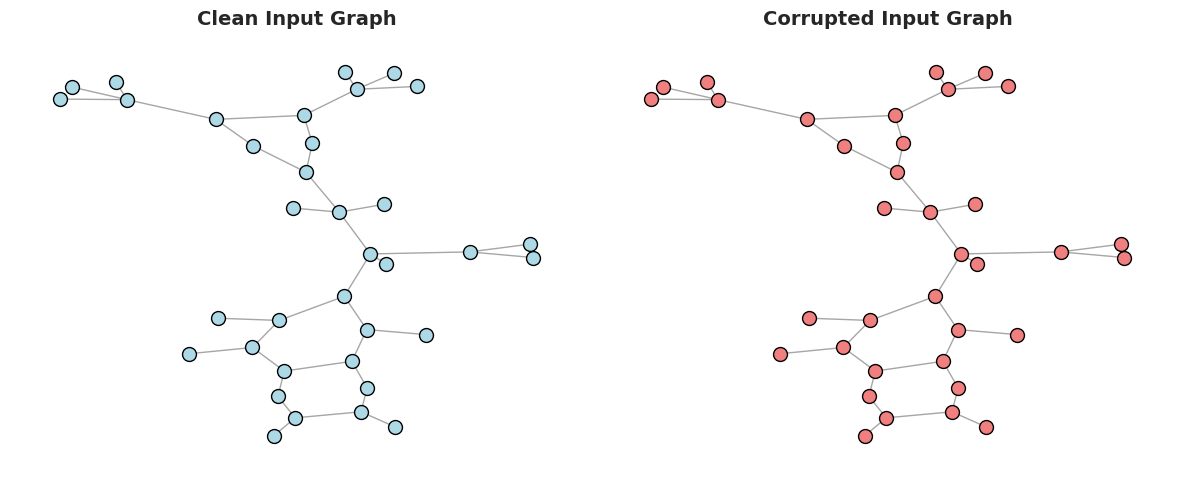

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (12,) + inhomogeneous part.

In [19]:
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from collections import defaultdict
from torch_geometric.utils import to_networkx

if 'MPNN_Attention' in data and data['MPNN_Attention']['micro'] and not df_micro.empty:
    # 1. Pick the absolute top graph
    top_g_idx = int(df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index'])
    
    # 2. Fetch directly from the FILTERED train dataset
    sample = train_cf_list[top_g_idx]
    clean_data = sample['clean']
    corrupted_data = sample['corrupted']

    # --- 3. PLOT CLEAN VS CORRUPTED SIDE-BY-SIDE ---
    G_clean = to_networkx(clean_data, to_undirected=True)
    G_corr = to_networkx(corrupted_data, to_undirected=True)
    pos_static = nx.spring_layout(G_clean, k=0.5, iterations=200, seed=42)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    nx.draw_networkx_nodes(G_clean, pos_static, ax=axes[0], node_size=100, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G_clean, pos_static, ax=axes[0], alpha=0.7, edge_color='gray')
    axes[0].set_title("Clean Input Graph", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    nx.draw_networkx_nodes(G_corr, pos_static, ax=axes[1], node_size=100, node_color='lightcoral', edgecolors='black')
    nx.draw_networkx_edges(G_corr, pos_static, ax=axes[1], alpha=0.7, edge_color='gray')
    axes[1].set_title("Corrupted Input Graph", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # --- 4. PREPARE ACTIVE-ONLY ATTENTION DATA ---
    micro_list_attn = data['MPNN_Attention']['micro']
    target_data = next(g for g in micro_list_attn if g['graph_index'] == top_g_idx)
    num_nodes = clean_data.num_nodes
    
    layer_attn_scores = defaultdict(list)
    active_heads_count = defaultdict(int) # This tracks survival for the title
    all_layers = set()

    for k, v in target_data['micro_scores'].items():
        if 'head' in k or k.endswith('.M'):
            match = re.search(r'layers\.(\d+)', k)
            if match:
                l_idx = int(match.group(1))
                all_layers.add(l_idx)
                
                # --- NEW: Check if this specific component survived pruning ---
                mask_val = masks.get(k, None)
                if mask_val is None and '.head_' in k:
                    parent_key = k.split('.head_')[0]
                    mask_val = masks.get(parent_key, 0)
                
                is_active = (mask_val > 0).any().item() if torch.is_tensor(mask_val) else mask_val > 0
                
                if is_active:
                    attn_matrix = v.numpy()
                    if attn_matrix.ndim == 3:
                        attn_matrix = np.mean(attn_matrix, axis=0)
                    layer_attn_scores[l_idx].append(attn_matrix)
                    active_heads_count[l_idx] += 1

    if not all_layers:
        print("No attention heads found.")
    else:
        # Calculate Mean Attention per layer
        layer_means = {}
        for l_idx in sorted(all_layers):
            mats = layer_attn_scores.get(l_idx, [])
            if mats:
                layer_means[l_idx] = np.mean(mats, axis=0)
            else:
                layer_means[l_idx] = np.zeros((num_nodes, num_nodes))
            
        sorted_layers = sorted(layer_means.keys())
        num_layers = len(sorted_layers)
        
        all_means = np.array(list(layer_means.values()))
        global_min, global_max = all_means.min(), all_means.max()
        
        # --- 5. SETUP ANIMATION FIGURE ---
        fig, ax = plt.subplots(figsize=(8, 8))
        cmap = plt.cm.plasma
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
        sm._A = []  
        fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04, label="Mean Active Attention")

        VISUAL_THRESHOLD = 0.20 # Lowered slightly to ensure edges are visible
        
        def update(frame):
            ax.clear()
            l_idx = sorted_layers[frame]
            mat = layer_means[l_idx]
            survived = active_heads_count[l_idx]
            
            if global_max > global_min:
                norm_mat = (mat - global_min) / (global_max - global_min + 1e-8)
            else:
                norm_mat = mat
            
            nx.draw_networkx_edges(G_clean, pos_static, ax=ax, edge_color='lightgray', alpha=0.3)
            
            G_attn = nx.DiGraph()
            for u in range(num_nodes):
                for v in range(num_nodes):
                    if norm_mat[u, v] > VISUAL_THRESHOLD:
                        G_attn.add_edge(u, v, weight=norm_mat[u, v])
            
            nx.draw_networkx_nodes(G_clean, pos_static, ax=ax, node_size=150, node_color='white', edgecolors='black')
            nx.draw_networkx_labels(G_clean, pos_static, ax=ax, font_size=8)
            
            edges = G_attn.edges(data=True)
            if edges:
                weights = [d['weight'] * 5 for u, v, d in edges]
                colors = [d['weight'] for u, v, d in edges]
                nx.draw_networkx_edges(G_attn, pos_static, ax=ax, width=weights, edge_color=colors, 
                                       edge_cmap=cmap, edge_vmin=0, edge_vmax=1,
                                       connectionstyle="arc3,rad=0.1", arrowsize=15, alpha=0.8)
            
            if survived == 0:
                ax.set_title(f"Layer {l_idx}: ALL HEADS PRUNED", color='red', fontsize=14, fontweight='bold')
            else:
                ax.set_title(f"Layer {l_idx}: {survived} Active Heads Survived", fontsize=14, fontweight='bold')
            ax.axis("off")
            
        anim = FuncAnimation(fig, update, frames=num_layers, interval=1000, repeat=True)
        plt.close(fig)
        display(HTML(anim.to_jshtml()))

In [21]:
# Grab the top graph's data again
top_g_idx = df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index']
target_data = next(g for g in data['MPNN_Attention']['micro'] if g['graph_index'] == top_g_idx)

print("--- ALL KEYS IN MICRO_SCORES ---")
for k, v in target_data['micro_scores'].items():
    print(f"Key: '{k}'  -->  Shape: {v.shape}")

--- ALL KEYS IN MICRO_SCORES ---
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_0'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_1'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_2'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_3'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_4'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_5'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_6'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_7'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_8'  -->  Shape: torch.Size([51, 51])
Key: 'hf_model.encoder.graph_encoder.layers.0.self_attn.M.head_9'  

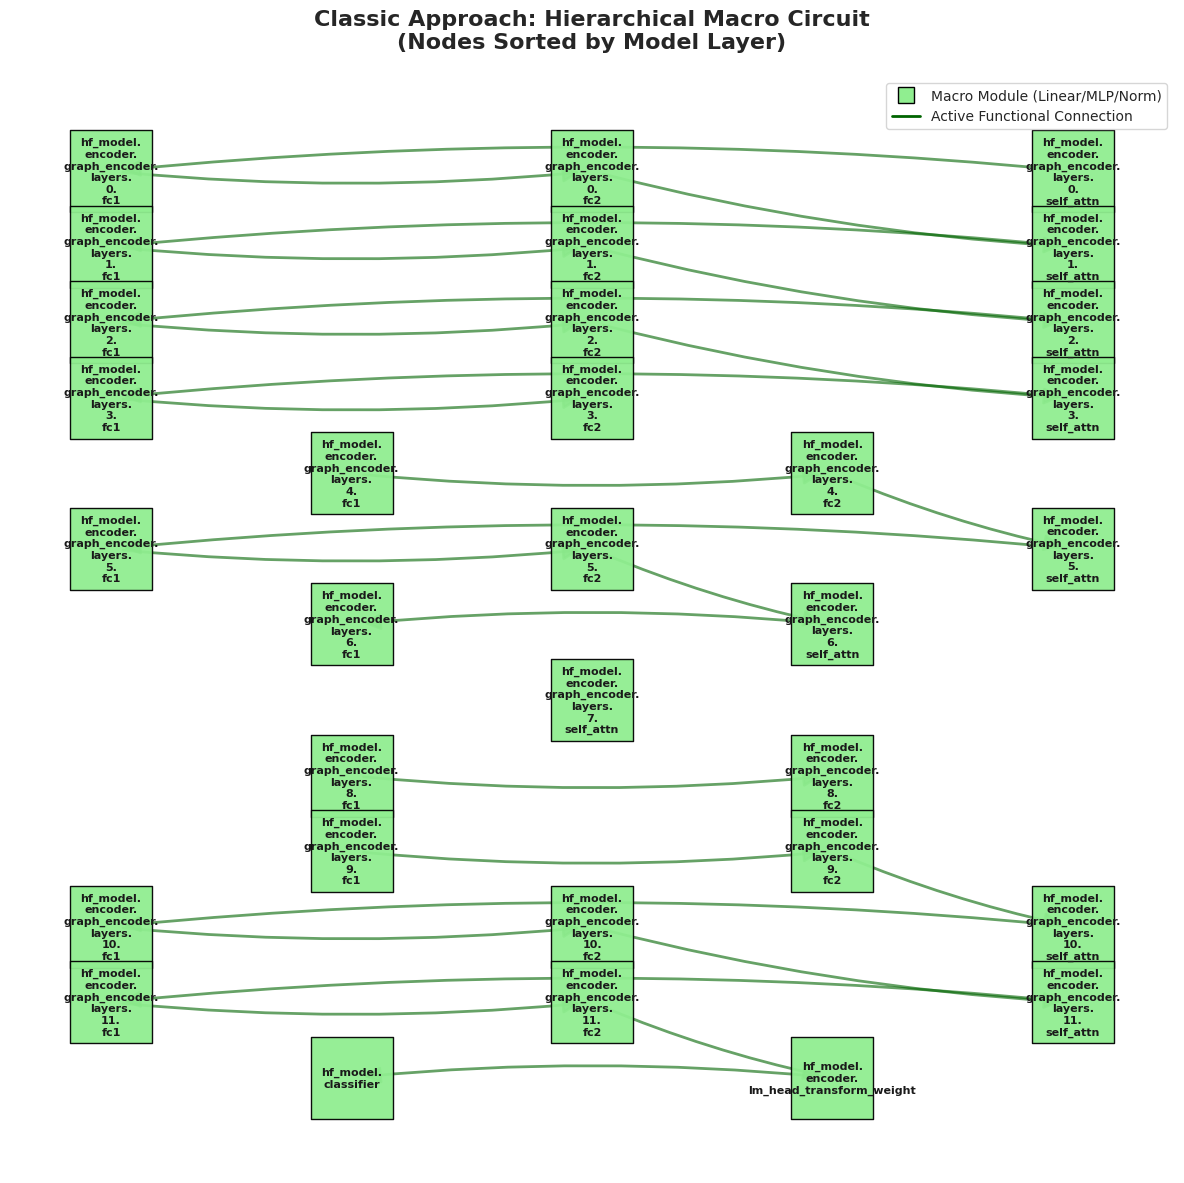

In [24]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. Load the Classic Macro Circuit
# This assumes the file is in your current directory or path
pkl_path = "./outputs/eap_results/zinc/graphformer/classic/optimal_macro_circuit.pkl"

try:
    with open(pkl_path, 'rb') as f:
        G = pickle.load(f)
except FileNotFoundError:
    print(f"Error: {pkl_path} not found. Please ensure the file exists.")
    G = None
if G:
    # 2. Logic to sort by Layer
    def get_layer_rank(node_name):
        # Extract layer index (e.g., 'layers.0.mlp' -> 0)
        layer_match = re.search(r'layers\.(\d+)', node_name)
        if layer_match:
            return int(layer_match.group(1))
        # Logic for pre/post processing
        if 'embedding' in node_name.lower() or 'input' in node_name.lower():
            return -1
        if 'head' in node_name.lower() or 'classifier' in node_name.lower():
            return 999
        return 50  # Default for middle components

    # Group nodes by their layer rank
    nodes = list(G.nodes())
    layer_map = {}
    for n in nodes:
        rank = get_layer_rank(n)
        if rank not in layer_map:
            layer_map[rank] = []
        layer_map[rank].append(n)

    # 3. Create Layered Layout (Multipartite-style)
    pos = {}
    sorted_ranks = sorted(layer_map.keys())
    for i, rank in enumerate(sorted_ranks):
        nodes_in_layer = sorted(layer_map[rank]) # Alphabetical sort within layer
        n_count = len(nodes_in_layer)
        for j, node in enumerate(nodes_in_layer):
            # X-coordinate: centered
            # Y-coordinate: top to bottom based on layer index
            pos[node] = (j - (n_count - 1) / 2.0, -i)

    # 4. Visualization
    plt.figure(figsize=(12, 12))
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='lightgreen', 
                           edgecolors='black', node_shape='s', alpha=0.95)
    
    # Draw Node Labels (wrapped for readability)
    labels = {n: n.replace('.', '.\n') for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold')

    # Draw Edges (Binary/Uniform as requested)
    # No EAP weight scaling - just showing existence of connection
    nx.draw_networkx_edges(G, pos, width=2.0, edge_color='darkgreen', 
                           arrowsize=25, connectionstyle="arc3,rad=0.05", alpha=0.6)

    # 5. Legend
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Macro Module (Linear/MLP/Norm)', 
               markerfacecolor='lightgreen', markersize=12, markeredgecolor='black'),
        Line2D([0], [0], color='darkgreen', lw=2, label='Active Functional Connection')
    ]
    plt.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10)

    plt.title("Classic Approach: Hierarchical Macro Circuit\n(Nodes Sorted by Model Layer)", 
              fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()